# ASSIGNMENT 06: RECURRENT NEURAL NETWORKS (RNN)
## Notebook 02: Dự Báo Doanh Thu Bán Lẻ Trực Tuyến Bằng PyTorch Vanilla RNN (Online Retail Dataset)
### Tích Hợp Toàn Diện: Khám Phá Dữ Liệu Giao Dịch, Tiền Xử Lý Chuỗi Thời Gian, Xây Dựng & Huấn Luyện Mô Hình RNN, Đánh Giá & So Sánh Kỹ Thuật

---

### Mục tiêu tổng thể của Notebook:
Notebook này cung cấp quy trình nghiên cứu học sâu hoàn chỉnh (End-to-End Deep Learning Pipeline) trên bộ dữ liệu kinh điển **Online Retail II** (UCI Machine Learning / Kaggle) với hai giai đoạn cốt lõi:

* **PHẦN 1: Chuẩn bị Dữ liệu & Tiền Xử Lý Chuỗi Thời Gian**:
  1. Kiểm tra nguồn dữ liệu thực tế `dataset/online_retail_II.csv` (hơn 1 triệu giao dịch).
  2. Phân tích chi tiết 8 cột đặc trưng, kiểu dữ liệu, missing values (`Customer ID`, `Description`), đơn hàng hủy (`Cancelled orders`), số lượng âm, đơn giá bất thường (`Price <= 0`), và thị trường quốc gia.
  3. Kỹ thuật tạo đặc trưng (Feature Engineering): Tính toán biến doanh thu `Revenue = Quantity × Price` và lọc giao dịch hợp lệ.
  4. Chuyển đổi dữ liệu giao dịch sang chuỗi thời gian (Daily Aggregation): Tạo 4 chỉ số `daily_revenue`, `daily_quantity`, `transaction_count`, `avg_order_value`. Lựa chọn biến mục tiêu cốt lõi: **`daily_revenue` (Doanh thu hàng ngày)**.
  5. Trực quan hóa dữ liệu khám phá (EDA): Phân bố doanh thu, xu hướng thời gian kèm SMA 7 quan sát và SMA 30 quan sát, sản lượng và số đơn hàng.
  6. Phân tích phân bố, dị biệt & tính mùa vụ: Skewness, outliers doanh thu bùng nổ, hiện tượng missing dates (phát hiện 104 ngày Thứ Bảy không có giao dịch sau lọc), kiểm chứng chu kỳ tuần và mùa vụ quý 4.
  7. Luận giải vì sao dataset phù hợp với RNN.
  8. Thiết kế bài toán dự báo: Lookback sequence length $L = 14$ ngày (14 ngày có giao dịch).
  9. Phân chia dữ liệu theo thời gian (70% Train, 15% Val, 15% Test) chống rò rỉ dữ liệu (Data Leakage).
  10. Chuẩn hóa dữ liệu bằng `MinMaxScaler(0, 1)`, fit nghiêm ngặt chỉ trên tập Train.
  11. Tạo cấu trúc cửa sổ trượt (Sliding Windows) tạo cặp Tensor 3D $(X, y)$.
  12. Đóng gói PyTorch Dataset & DataLoader (`batch_size = 16`, `shuffle=False`).
  13. Bảng tổng kết thông số sẵn sàng huấn luyện (`Ready for PyTorch RNN`).

* **PHẦN 2: Xây Dựng, Huấn Luyện & Đánh Giá Mô Hình PyTorch RNN**:
  14. Thiết lập tính tái lập (Reproducibility: Random Seed) và thông tin thiết bị phần cứng.
  15. Xây dựng kiến trúc mô hình Vanilla RNN: `Input -> torch.nn.RNN -> Linear -> Prediction` (không dùng LSTM/GRU).
  16. Cấu hình Loss (`nn.MSELoss`) và Optimizer (`optim.Adam`).
  17. Viết Training Loop hoàn chỉnh kèm cơ chế Validation mỗi epoch.
  18. Theo dõi, vẽ biểu đồ Learning Curve và phân tích 3 trạng thái: Underfitting, Overfitting và Convergence.
  19. Thực hiện dự đoán trên Test Set và khôi phục thang đo gốc bằng `inverse_transform`.
  20. Đánh giá đa chiều với bộ chỉ số định lượng: MAE, MSE, RMSE, MAPE, WAPE, sMAPE và phân tích chuyên sâu về tính ổn định của MAPE khi giá trị thực tế gần hoặc bằng 0.
  21. Trực quan hóa so sánh Thực tế vs Dự đoán (Actual vs Predicted) và phần dư theo thời gian.
  22. Phân tích chuyên sâu kết quả: Mẫu hình học được, giai đoạn sai lệch, tác động của outlier, tác động của missing dates và giới hạn của việc aggregate chuỗi ngày.
  23. So sánh kỹ thuật toàn diện giữa bài toán Bán lẻ Online Retail và bài toán Chứng khoán S&P 500 (Notebook 01).
  24. Tổng kết toàn diện dự án (`Conclusion`).

---

### Bảng Mục Lục Điều Hướng:
#### PHẦN 1: EDA, TIỀN XỬ LÝ & CHUẨN BỊ DỮ LIỆU
1. [Xác định & Đọc file Dataset thực tế](#section-1)
2. [Phân tích chi tiết Dataset giao dịch gốc](#section-2)
3. [Tạo biến Doanh thu (Revenue) & Lọc giao dịch hợp lệ](#section-3)
4. [Chuyển đổi dữ liệu giao dịch thành chuỗi thời gian (Daily Aggregation)](#section-4)
5. [Khám phá & Trực quan hóa dữ liệu chuỗi thời gian (EDA)](#section-5)
6. [Phân tích phân bố, dị biệt & tính mùa vụ (Seasonality & Outliers)](#section-6)
7. [Vì sao Dataset phù hợp với mô hình RNN?](#section-7)
8. [Chuẩn hóa thiết kế bài toán dự đoán (Lookback Window)](#section-8)
9. [Phân chia Train / Validation / Test theo trục thời gian](#section-9)
10. [Chuẩn hóa dữ liệu (Scaling) & Phòng chống Data Leakage](#section-10)
11. [Tạo cấu trúc Sliding Window (X, y)](#section-11)
12. [Xây dựng PyTorch Dataset & DataLoader](#section-12)
13. [Ready for PyTorch RNN (Bảng tổng kết chuẩn bị huấn luyện)](#section-13)

#### PHẦN 2: XÂY DỰNG, HUẤN LUYỆN, ĐÁNH GIÁ & SO SÁNH KỸ THUẬT
14. [Reproducibility & Thiết Lập Môi Trường (Random Seed, Device, Version)](#section-14)
15. [Xây Dựng Mô Hình Vanilla RNN Với PyTorch (`torch.nn.RNN`)](#section-15)
16. [Cấu Hình Hàm Mất Mát (Loss) & Thuật Toán Tối Ưu (Optimizer)](#section-16)
17. [Quy Trình Huấn Luyện (Training Loop) & Validation](#section-17)
18. [Theo Dõi Quá Trình Huấn Luyện & Biểu Đồ Learning Curve](#section-18)
19. [Dự Đoán Trên Test Set & Khôi Phục Thang Đo Gốc (Inverse Transform)](#section-19)
20. [Đánh Giá Hiệu Năng Mô Hình (Metrics & Xử Lý MAPE Khi Actual Gần/Bằng 0)](#section-20)
21. [Trực Quan Hóa Kết Quả Dự Đoán (Actual vs Predicted)](#section-21)
22. [Phân Tích Chuyên Sâu Kết Quả Dự Báo Bán Lẻ](#section-22)
23. [So Sánh Kỹ Thuật Toàn Diện Với Dataset Chứng Khoán S&P 500](#section-23)
24. [Conclusion (Tổng Kết Cuối Cùng)](#section-24)


---
<a id="section-1"></a>
## 1. Xác Định & Đọc File Dataset Thực Tế

### 1.1. Kiểm tra môi trường & Nguồn gốc dữ liệu:
* **Bộ dữ liệu**: Online Retail II Data Set
* **Nguồn**: Kaggle - *Online Retail Dataset* (tác giả Lakshmi) / UCI Machine Learning Repository. [Link Kaggle Dataset](https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset)
* **Đường dẫn thực tế trong dự án**: `dataset/online_retail_II.csv` (dung lượng $\approx 90$ MB).
* Dữ liệu ghi nhận toàn bộ các giao dịch thực tế diễn ra từ ngày **01/12/2009** đến ngày **09/12/2011** của một công ty bán lẻ trực tuyến tại Vương Quốc Anh (UK-based online retail), chuyên bán các mặt hàng quà tặng độc đáo cho cả khách mua sỉ và khách lẻ.

Đoạn code bên dưới kiểm tra file tồn tại và tải dữ liệu bằng `pd.read_csv`.


In [1]:
# 1. Kiểm tra đường dẫn và đọc dataset thực tế
import os
import pandas as pd
import numpy as np

retail_csv_path = os.path.join("dataset", "online_retail_II.csv")

if not os.path.exists(retail_csv_path):
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu tại đường dẫn: {retail_csv_path}")

file_size_mb = os.path.getsize(retail_csv_path) / (1024 * 1024)
print(f"-> Đã xác thực file dataset tồn tại tại: {retail_csv_path}")
print(f"-> Dung lượng file trên đĩa: {file_size_mb:.2f} MB")

# Đọc dữ liệu thô vào Pandas DataFrame (sử dụng low_memory=False để tối ưu kiểu dữ liệu)
df_raw = pd.read_csv(retail_csv_path, low_memory=False)
print(f"-> Đọc dữ liệu thành công! Tổng số dòng: {len(df_raw):,}, Tổng số cột: {df_raw.shape[1]}")


-> Đã xác thực file dataset tồn tại tại: dataset\online_retail_II.csv
-> Dung lượng file trên đĩa: 89.88 MB


-> Đọc dữ liệu thành công! Tổng số dòng: 1,067,371, Tổng số cột: 8


---
<a id="section-2"></a>
## 2. Phân Tích Chi Tiết Dataset Giao Dịch Gốc

### 2.1. Cấu trúc tổng thể của 8 cột đặc trưng:
Bộ dữ liệu gồm **1,067,371 dòng** và **8 cột** với ý nghĩa cụ thể như sau:
1. `Invoice`: Mã số hóa đơn giao dịch (6 chữ số). Nếu mã bắt đầu bằng chữ cái **`C`** (ví dụ `C489449`), đó là hóa đơn hủy hoặc hoàn trả hàng (**Cancellation**).
2. `StockCode`: Mã định danh duy nhất của sản phẩm/mặt hàng (5 chữ số hoặc ký tự đặc biệt).
3. `Description`: Tên hoặc mô tả ngắn về sản phẩm.
4. `Quantity`: Số lượng mặt hàng trong mỗi dòng đơn hàng. Giá trị có thể **âm** nếu là giao dịch trả hàng/hủy hàng.
5. `InvoiceDate`: Ngày và giờ chính xác phát sinh hóa đơn giao dịch (định dạng `YYYY-MM-DD HH:MM:SS`).
6. `Price`: Đơn giá của từng sản phẩm tính bằng đồng **Bảng Anh (GBP - £)**.
7. `Customer ID`: Mã định danh duy nhất của từng khách hàng (5 chữ số).
8. `Country`: Tên quốc gia nơi khách hàng sinh sống / địa chỉ giao hàng.

---

### 2.2. Kiểm tra chất lượng và các điểm dị biệt (Data Anomalies):
* **Kiểu dữ liệu (Datatypes)**: `Invoice`, `StockCode`, `Description`, `Country` là dạng chuỗi (Object); `Quantity` là số nguyên (Int64); `Price` và `Customer ID` là số thực (Float64); `InvoiceDate` cần được chuyển sang Datetime chuẩn.
* **Missing Values**:
  * Cột `Customer ID` bị rỗng **243,007 dòng** (~$22.77\%$). Dataset không cho biết nguyên nhân thiếu mã khách hàng; giữ các dòng này khi tổng hợp doanh số.
  * Cột `Description` bị rỗng **4,382 dòng** (~$0.41\%$).
  * Các cột quan trọng khác (`Invoice`, `StockCode`, `Quantity`, `InvoiceDate`, `Price`, `Country`) hoàn toàn **không có giá trị rỗng**.
* **Dòng trùng lặp (Duplicates)**: Toàn bộ bảng có **34,335 dòng trùng lặp hoàn toàn**.
* **Đơn hàng hủy (Cancelled Orders)**: Có **19,494 dòng** có mã hóa đơn bắt đầu bằng ký tự `'C'`.
* **Số lượng âm (`Quantity < 0`)**: Có **22,950 dòng** có số lượng nhỏ hơn 0 (phần lớn là các giao dịch hủy `'C'`, điều chỉnh hàng hỏng hoặc mất mát kho).
* **Đơn giá bất thường (`Price <= 0`)**: Có **6,207 dòng** có đơn giá bằng 0 hoặc âm (hàng mẫu tặng kèm, quà tặng khuyến mãi, hoặc các bút toán điều chỉnh kế toán nội bộ như *"Adjust bad debt"*).
* **Thời gian giao dịch**: Từ ngày **`01/12/2009 07:45`** đến **`09/12/2011 12:50`** (hơn 2 năm liên tục, tương đương 739 ngày dương lịch).
* **Thị trường quốc gia**: Gồm **43 quốc gia**, trong đó Vương Quốc Anh (**United Kingdom**) áp đảo tuyệt đối với hơn **981,330 dòng** (~$92\%$ tổng số quan sát).
* **Khách hàng**: Có **5,942 khách hàng duy nhất** có mã định danh.


In [2]:
# In thông tin tổng quan, kiểu dữ liệu và kiểm tra dị biệt của dataset thô
print("=== 1. NĂM DÒNG ĐẦU TIÊN CỦA DATASET THÔ ===")
display(df_raw.head())

print("\n=== 2. THỐNG KÊ KIỂU DỮ LIỆU & BỘ NHỚ ===")
df_raw.info()

print("\n=== 3. THỐNG KÊ GIÁ TRỊ RỖNG (MISSING VALUES) ===")
missing_count = df_raw.isnull().sum()
missing_percent = (missing_count / len(df_raw)) * 100
df_missing_summary = pd.DataFrame({'Số dòng thiếu': missing_count, 'Tỷ lệ (%)': missing_percent})
display(df_missing_summary)

print("\n=== 4. THỐNG KÊ DÒNG TRÙNG LẶP & ĐƠN HÀNG HỦY ===")
print(f"Số dòng trùng lặp hoàn toàn (Duplicates): {df_raw.duplicated().sum():,}")

df_raw['InvoiceStr'] = df_raw['Invoice'].astype(str)
cancelled_mask = df_raw['InvoiceStr'].str.startswith('C')
print(f"Số hóa đơn hủy (Bắt đầu bằng chữ 'C'): {cancelled_mask.sum():,} dòng")
print(f"Số dòng có Quantity < 0: {(df_raw['Quantity'] < 0).sum():,} dòng")
print(f"Số dòng có Price <= 0   : {(df_raw['Price'] <= 0).sum():,} dòng")

print("\n=== 5. PHẠM VI THỜI GIAN & TOP QUỐC GIA ===")
temp_dates = pd.to_datetime(df_raw['InvoiceDate'])
print(f"Mốc thời gian bắt đầu: {temp_dates.min()}")
print(f"Mốc thời gian kết thúc: {temp_dates.max()}")
print(f"Tổng số khách hàng duy nhất: {df_raw['Customer ID'].nunique():,} khách hàng")
print(f"Tổng số hóa đơn duy nhất: {df_raw['Invoice'].nunique():,} hóa đơn")
print("\nTop 5 quốc gia có nhiều giao dịch nhất:")
print(df_raw['Country'].value_counts().head(5))


=== 1. NĂM DÒNG ĐẦU TIÊN CỦA DATASET THÔ ===


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



=== 2. THỐNG KÊ KIỂU DỮ LIỆU & BỘ NHỚ ===
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB

=== 3. THỐNG KÊ GIÁ TRỊ RỖNG (MISSING VALUES) ===


,Số dòng thiếu,Tỷ lệ (%)
Invoice,0,0.000000
StockCode,0,0.000000
Description,4382,0.410541
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,243007,22.766873
Country,0,0.000000



=== 4. THỐNG KÊ DÒNG TRÙNG LẶP & ĐƠN HÀNG HỦY ===


Số dòng trùng lặp hoàn toàn (Duplicates): 34,335
Số hóa đơn hủy (Bắt đầu bằng chữ 'C'): 19,494 dòng
Số dòng có Quantity < 0: 22,950 dòng
Số dòng có Price <= 0   : 6,207 dòng

=== 5. PHẠM VI THỜI GIAN & TOP QUỐC GIA ===


Mốc thời gian bắt đầu: 2009-12-01 07:45:00
Mốc thời gian kết thúc: 2011-12-09 12:50:00
Tổng số khách hàng duy nhất: 5,942 khách hàng
Tổng số hóa đơn duy nhất: 53,628 hóa đơn

Top 5 quốc gia có nhiều giao dịch nhất:
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Name: count, dtype: int64


---
<a id="section-3"></a>
## 3. Tạo Biến Doanh Thu (Revenue) & Lọc Giao Dịch Hợp Lệ

### 3.1. Tính toán biến Doanh thu (Revenue):
* Trong tập dữ liệu bán lẻ thô, chúng ta có số lượng sản phẩm mua (`Quantity`) và đơn giá của sản phẩm đó (`Price` tính bằng GBP £).
* Biến **Doanh thu (`Revenue`)** được tính theo công thức:
  $$\text{Revenue} = \text{Quantity} \times \text{Price}$$
* **Ý nghĩa toán học và kinh tế**:
  * `Revenue` là một **biến dẫn xuất (Derived Feature)** từ dữ liệu gốc, đại diện cho giá trị ghi nhận trên dòng giao dịch cho từng mặt hàng trong đơn hàng.
  * Đây là biến số quan trọng nhất để làm nền tảng tính toán doanh số tổng của toàn bộ doanh nghiệp.

---

### 3.2. Tiêu chí làm sạch dữ liệu giao dịch hợp lệ:
Để phục vụ bài toán dự báo nhu cầu bán hàng và dòng tiền trong tương lai, chúng ta cần loại bỏ các bản ghi nằm ngoài định nghĩa doanh số bán dương của bài:
1. **Loại bỏ đơn hủy**: Bỏ các dòng có `Invoice` bắt đầu bằng chữ `'C'`.
2. **Loại bỏ số lượng không hợp lệ**: Giữ lại các dòng có `Quantity > 0`.
3. **Loại bỏ đơn giá không hợp lệ**: Giữ lại các dòng có `Price > 0` (loại bỏ các mục quà tặng 0đ, chiết khấu và bút toán điều chỉnh công nợ).
4. **Loại bỏ dòng trùng lặp hoàn toàn**: Giả định các dòng trùng hoàn toàn là bản ghi lặp và giữ một bản.


> **Quy ước mục tiêu**: Trong notebook này, “doanh thu” / `daily_revenue` là **tổng giá trị các dòng bán dương sau lọc**, chưa khấu trừ hủy/hoàn trả; không phải doanh thu thuần hoặc dòng tiền thực thu. Loại bản ghi trùng hoàn toàn là giả định làm sạch, không phải bằng chứng mọi dòng giống nhau đều là nhập trùng. Các nhóm dòng hủy, số lượng âm và giá không dương có thể chồng lấp, nên không cộng các số đếm riêng thành tổng số dòng bị loại.

> **Đối chiếu dữ liệu gốc**: Dòng bán `581483`, mã hàng `23843`, số lượng `80,995`, giá `£2.08` có giá trị `£168,469.60` lúc 09:15 ngày 09/12/2011. Dòng hủy `C581484` có cùng mã hàng, đơn giá và số lượng đối ứng lúc 09:27. Pipeline giữ dòng bán và loại dòng hủy; vì vậy không diễn giải đỉnh ngày này thành doanh thu thuần đã thực hiện.


In [3]:
# Thực hiện làm sạch và tính toán biến Doanh thu (Revenue)
# 1. Loại bỏ các dòng trùng lặp
df_clean = df_raw.drop_duplicates().copy()

# 2. Lọc các giao dịch bán hàng hợp lệ: Không phải đơn hủy 'C', Quantity > 0 và Price > 0
valid_mask = (
    (~df_clean['InvoiceStr'].str.startswith('C')) & 
    (df_clean['Quantity'] > 0) & 
    (df_clean['Price'] > 0)
)
df_clean = df_clean[valid_mask].copy()

# 3. Chuẩn hóa cột InvoiceDate sang datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Date'] = pd.to_datetime(df_clean['InvoiceDate'].dt.date)

# 4. Tạo biến dẫn xuất Revenue = Quantity * Price
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

print(f"Số lượng giao dịch ban đầu : {len(df_raw):,} dòng")
print(f"Số lượng giao dịch hợp lệ  : {len(df_clean):,} dòng (Giữ lại {len(df_clean)/len(df_raw)*100:.2f}%)")
print(f"Tổng doanh thu tích lũy hợp lệ qua 2 năm: £{df_clean['Revenue'].sum():,.2f} GBP")
display(df_clean[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Revenue', 'Date']].head(3))


# Kiểm tra nguồn gốc đỉnh bán hàng: dòng bán lớn có dòng hủy đối ứng.
invoice_text = df_raw["Invoice"].astype(str)
audit_rows = df_raw.loc[invoice_text.isin(["581483", "C581484"]),
                        ["Invoice", "StockCode", "Quantity", "InvoiceDate", "Price"]].copy()
audit_rows["LineValue"] = audit_rows["Quantity"] * audit_rows["Price"]
print("\n=== ĐỐI CHIẾU DÒNG BÁN VÀ DÒNG HỦY TRONG DỮ LIỆU GỐC ===")
display(audit_rows)
print("-> Target là doanh số các dòng bán dương sau lọc; chưa khấu trừ hủy/hoàn trả, không phải doanh thu thuần.")


Số lượng giao dịch ban đầu : 1,067,371 dòng
Số lượng giao dịch hợp lệ  : 1,007,913 dòng (Giữ lại 94.43%)
Tổng doanh thu tích lũy hợp lệ qua 2 năm: £20,476,260.45 GBP


,Invoice,StockCode,Description,Quantity,Price,Revenue,Date
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,83.4,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,81.0,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,81.0,2009-12-01



=== ĐỐI CHIẾU DÒNG BÁN VÀ DÒNG HỦY TRONG DỮ LIỆU GỐC ===


,Invoice,StockCode,Quantity,InvoiceDate,Price,LineValue
1065882,581483,23843,80995,2011-12-09 09:15:00,2.08,168469.6
1065883,C581484,23843,-80995,2011-12-09 09:27:00,2.08,-168469.6


-> Target là doanh số các dòng bán dương sau lọc; chưa khấu trừ hủy/hoàn trả, không phải doanh thu thuần.


---
<a id="section-4"></a>
## 4. Chuyển Đổi Dữ Liệu Giao Dịch Thành Chuỗi Thời Gian (Daily Aggregation)

### 4.1. Tại sao không thể đưa từng giao dịch trực tiếp vào RNN một cách máy móc?
1. **Tính chất bất đồng bộ (Asynchronous / Irregular timestamps)**:
   * Các giao dịch mua sắm diễn ra ngẫu nhiên theo từng giây, từng phút. Có phút phát sinh 20 đơn hàng, nhưng có ban đêm hàng giờ liền không có giao dịch nào.
   * RNN xử lý các bước tuần tự. Ở đây tổng hợp theo ngày để giảm số dòng; khoảng cách giữa các ngày được giữ lại có thể không đều theo lịch.
2. **Khối lượng dữ liệu khổng lồ và độ nhiễu cao**:
   * Hơn 1 triệu giao dịch lẻ chứa đầy nhiễu vi mô của từng khách hàng cá nhân.
   * Mục tiêu quản trị kinh doanh thực tế là dự báo **doanh thu tổng theo ngày/tuần** để hoạch định nguồn lực, chứ không phải đoán từng giây có ai bấm nút mua hàng hay không.

---

### 4.2. Quy trình tổng hợp theo ngày (Daily Aggregation):
Chúng ta nhóm các giao dịch theo ngày (`Date`) và tính toán 4 chỉ số chuỗi thời gian then chốt:
* `daily_revenue`: Tổng doanh thu phát sinh trong ngày (GBP £).
* `daily_quantity`: Tổng số lượng sản phẩm được mua trong ngày.
* `transaction_count`: Số lượng hóa đơn giao dịch độc lập (`Invoice` duy nhất) trong ngày.
* `avg_order_value`: Giá trị trung bình trên mỗi đơn hàng trong ngày (AOV = `daily_revenue / transaction_count`).

---

### 4.3. Lựa chọn Target cốt lõi: `daily_revenue`
* **Target được chọn**: **Doanh thu ngày tiếp theo (`daily_revenue` tại thời điểm $t+1$)**.
* **Lý do lựa chọn**:
  * Doanh thu là chỉ số sống còn (North Star Metric) đối với mọi doanh nghiệp bán lẻ thương mại điện tử.
  * Dự báo chính xác doanh thu giúp doanh nghiệp tối ưu hóa dòng tiền hoạt động, điều tiết ngân sách quảng cáo marketing theo từng ngày trong tuần, và chủ động chuẩn bị nhân lực kho vận đóng gói.


> **Quy ước thời gian**: Chỉ giữ **ngày có giao dịch sau lọc**, không tự điền 0 cho ngày thiếu khi chưa biết nguyên nhân. Một bước là quan sát kế tiếp, không nhất thiết ngày lịch kế tiếp. Các SMA 7/30 tính trên 7/30 quan sát, không phải đúng một tuần/tháng. RNN có thể nhận chuỗi sự kiện không đều; nếu muốn biểu diễn khoảng cách thời gian cần bổ sung đặc trưng lịch.


In [4]:
# Thực hiện tổng hợp dữ liệu giao dịch theo từng ngày (Daily Aggregation)
daily_df = df_clean.groupby('Date').agg(
    daily_revenue=('Revenue', 'sum'),
    daily_quantity=('Quantity', 'sum'),
    transaction_count=('Invoice', 'nunique')
).reset_index()

# Tính giá trị trung bình trên mỗi đơn hàng (Average Order Value - AOV)
daily_df['avg_order_value'] = daily_df['daily_revenue'] / daily_df['transaction_count']

# Sắp xếp nghiêm ngặt theo trật tự thời gian tăng dần
daily_df = daily_df.sort_values('Date').reset_index(drop=True)

print("=== THÔNG SỐ CHUỖI THỜI GIAN THEO NGÀY (DAILY TIME SERIES) ===")
print(f"Tổng số ngày ghi nhận bán hàng: {len(daily_df)} ngày.")
print(f"Ngày bắt đầu: {daily_df['Date'].min().strftime('%Y-%m-%d')}")
print(f"Ngày kết thúc: {daily_df['Date'].max().strftime('%Y-%m-%d')}")
print("\n5 ngày đầu tiên của chuỗi:")
display(daily_df.head(5))


=== THÔNG SỐ CHUỖI THỜI GIAN THEO NGÀY (DAILY TIME SERIES) ===

Tổng số ngày ghi nhận bán hàng: 604 ngày.
Ngày bắt đầu: 2009-12-01
Ngày kết thúc: 2011-12-09

5 ngày đầu tiên của chuỗi:


,Date,daily_revenue,daily_quantity,transaction_count,avg_order_value
0,2009-12-01,54351.23,26098,119,456.733025
1,2009-12-02,63172.58,31804,115,549.326783
2,2009-12-03,73972.45,49221,124,596.552016
3,2009-12-04,40582.32,21210,89,455.981124
4,2009-12-05,9803.05,5119,30,326.768333


---
<a id="section-5"></a>
## 5. Khám Phá & Trực Quan Hóa Dữ Liệu Chuỗi Thời Gian (EDA)

Để thấu hiểu sâu sắc cấu trúc chuỗi thời gian, chúng ta tiến hành trực quan hóa 4 đồ thị chuyên sâu:
1. **Phân bố của Doanh thu hàng ngày (`daily_revenue`)**: Histogram kết hợp KDE và Boxplot để đánh giá độ lệch và khoảng tứ phân vị.
2. **Doanh thu hàng ngày theo thời gian**: Kèm theo hai đường trung bình động SMA 7 quan sát (xu hướng ngắn hạn) và SMA 30 quan sát (xu hướng trung hạn).
3. **Sản lượng hàng bán (`daily_quantity`) theo thời gian**: Đánh giá khối lượng hàng hóa vận chuyển.
4. **Số lượng đơn hàng (`transaction_count`) theo thời gian**: Đánh giá lưu lượng khách hàng giao dịch.

Sau mỗi đồ thị, chúng ta phân tích chi tiết ý nghĩa thực tiễn đối với bài toán học máy và mô hình RNN.


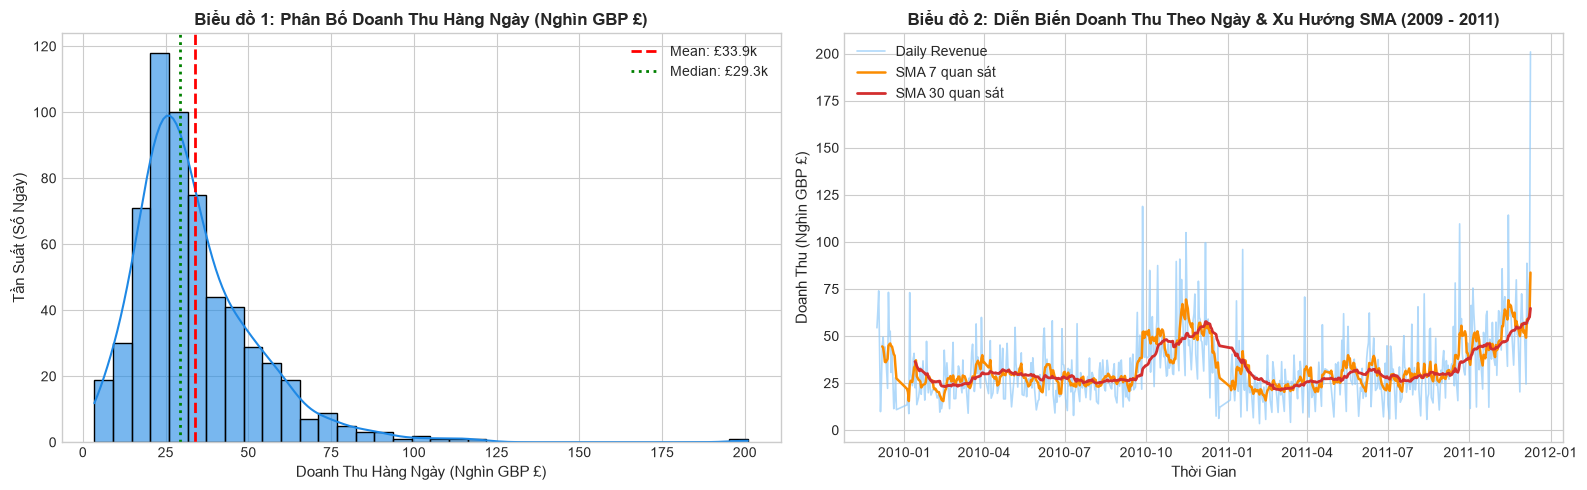

In [5]:
# Trực quan hóa Biểu đồ 1: Phân bố Doanh thu & Biểu đồ 2: Doanh thu theo thời gian
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- BIỂU ĐỒ 1: PHÂN BỐ DAILY REVENUE ---
sns.histplot(daily_df['daily_revenue'] / 1e3, kde=True, ax=axes[0], color='#1E88E5', bins=35, edgecolor='black', alpha=0.6)
axes[0].axvline(daily_df['daily_revenue'].mean() / 1e3, color='red', linestyle='--', linewidth=2, 
                label=f"Mean: £{daily_df['daily_revenue'].mean()/1e3:.1f}k")
axes[0].axvline(daily_df['daily_revenue'].median() / 1e3, color='green', linestyle=':', linewidth=2, 
                label=f"Median: £{daily_df['daily_revenue'].median()/1e3:.1f}k")
axes[0].set_title("Biểu đồ 1: Phân Bố Doanh Thu Hàng Ngày (Nghìn GBP £)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Doanh Thu Hàng Ngày (Nghìn GBP £)", fontsize=11)
axes[0].set_ylabel("Tần Suất (Số Ngày)", fontsize=11)
axes[0].legend(fontsize=10)

# --- BIỂU ĐỒ 2: DAILY REVENUE THEO THỜI GIAN VÀ ĐƯỜNG TRUNG BÌNH ĐỘNG (SMA) ---
daily_df['SMA_7'] = daily_df['daily_revenue'].rolling(window=7).mean()
daily_df['SMA_30'] = daily_df['daily_revenue'].rolling(window=30).mean()

axes[1].plot(daily_df['Date'], daily_df['daily_revenue'] / 1e3, label='Daily Revenue', color='#90CAF9', linewidth=1.2, alpha=0.7)
axes[1].plot(daily_df['Date'], daily_df['SMA_7'] / 1e3, label='SMA 7 quan sát', color='#FB8C00', linewidth=1.8)
axes[1].plot(daily_df['Date'], daily_df['SMA_30'] / 1e3, label='SMA 30 quan sát', color='#D32F2F', linewidth=2.0)
axes[1].set_title("Biểu đồ 2: Diễn Biến Doanh Thu Theo Ngày & Xu Hướng SMA (2009 - 2011)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Thời Gian", fontsize=11)
axes[1].set_ylabel("Doanh Thu (Nghìn GBP £)", fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


### Ý Nghĩa Của Biểu Đồ 1 & 2 Đối Với Bài Toán Forecasting:

#### 1. Ý nghĩa của Biểu đồ 1 (Phân bố doanh thu hàng ngày):
* **Phân bố lệch phải**: Mean **£33,901.09**, median **£29,325.73**, skewness **2.189**. Một số ngày có doanh số lớn kéo trung bình lên cao hơn trung vị.
* **Ý nghĩa đối với mô hình hóa**: Các giá trị lớn tác động mạnh tới MSE. Chuẩn hóa giúp cân bằng thang đo, nhưng không loại bỏ độ lệch hay tác động của outlier.

#### 2. Ý nghĩa của Biểu đồ 2 (Doanh thu theo thời gian & Đường trung bình động SMA):
* **Dao động theo thời gian**: Biểu đồ cho thấy mức doanh số và biên độ biến động thay đổi, có các đỉnh lớn về cuối chuỗi.
* **SMA 7 và 30 quan sát** làm mịn chuỗi. Vì thiếu ngày lịch, không đồng nhất các đường này với chu kỳ tuần/tháng.
* Dữ liệu gợi ý khác biệt giữa các giai đoạn trong năm; biểu đồ đơn thuần chưa chứng minh nguyên nhân lễ hội hoặc khả năng RNN dự báo tốt.


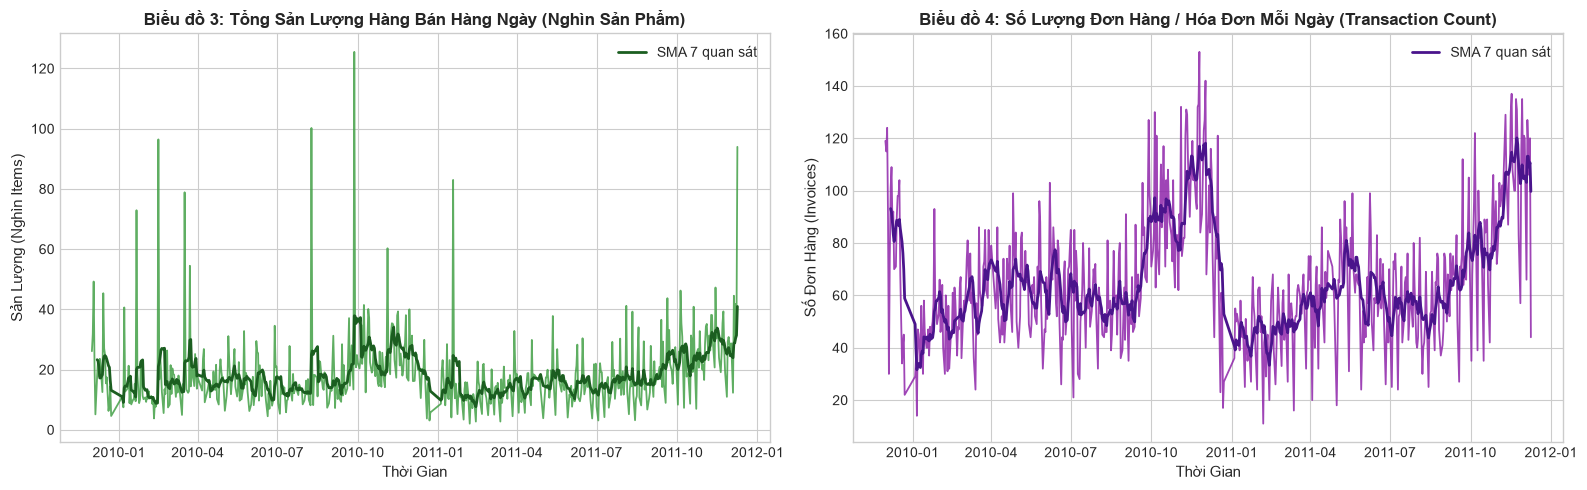

=== MA TRẬN HỆ SỐ TƯƠNG QUAN TUYẾN TÍNH (PEARSON CORRELATION) ===


,daily_revenue,daily_quantity,transaction_count,avg_order_value
daily_revenue,1.000,0.784,0.678,0.715
daily_quantity,0.784,1.000,0.519,0.581
transaction_count,0.678,0.519,1.000,0.031
avg_order_value,0.715,0.581,0.031,1.000


In [6]:
# Trực quan hóa Biểu đồ 3: Sản lượng hàng ngày & Biểu đồ 4: Số lượng đơn hàng
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- BIỂU ĐỒ 3: SẢN LƯỢNG HÀNG BÁN HÀNG NGÀY (DAILY QUANTITY) ---
axes[0].plot(daily_df['Date'], daily_df['daily_quantity'] / 1e3, color='#43A047', linewidth=1.3, alpha=0.85)
axes[0].plot(daily_df['Date'], daily_df['daily_quantity'].rolling(7).mean() / 1e3, color='#1B5E20', linewidth=2, label='SMA 7 quan sát')
axes[0].set_title("Biểu đồ 3: Tổng Sản Lượng Hàng Bán Hàng Ngày (Nghìn Sản Phẩm)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Thời Gian", fontsize=11)
axes[0].set_ylabel("Sản Lượng (Nghìn Items)", fontsize=11)
axes[0].legend(fontsize=10)

# --- BIỂU ĐỒ 4: SỐ LƯỢNG GIAO DỊCH HÀNG NGÀY (TRANSACTION COUNT) ---
axes[1].plot(daily_df['Date'], daily_df['transaction_count'], color='#8E24AA', linewidth=1.3, alpha=0.85)
axes[1].plot(daily_df['Date'], daily_df['transaction_count'].rolling(7).mean(), color='#4A148C', linewidth=2, label='SMA 7 quan sát')
axes[1].set_title("Biểu đồ 4: Số Lượng Đơn Hàng / Hóa Đơn Mỗi Ngày (Transaction Count)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Thời Gian", fontsize=11)
axes[1].set_ylabel("Số Đơn Hàng (Invoices)", fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Tính toán ma trận tương quan giữa 4 đặc trưng chuỗi thời gian
corr_matrix = daily_df[['daily_revenue', 'daily_quantity', 'transaction_count', 'avg_order_value']].corr()
print("=== MA TRẬN HỆ SỐ TƯƠNG QUAN TUYẾN TÍNH (PEARSON CORRELATION) ===")
display(corr_matrix.style.background_gradient(cmap='Blues', axis=None).format("{:.3f}"))


### Ý Nghĩa Của Biểu Đồ 3 & 4 Đối Với Bài Toán Forecasting:

#### 1. Mối tương quan đồng pha giữa Sản lượng và Doanh thu:
* **Pearson trên chuỗi đã lọc**: `daily_revenue` tương quan **0.784** với `daily_quantity`, **0.678** với `transaction_count`.
* Đây là tương quan **cùng ngày**, không chứng minh các đặc trưng dự báo được doanh số ngày sau hoặc có quan hệ nhân quả.
* Mô hình chỉ nhận các đặc trưng của những ngày trước target. Muốn khẳng định lợi ích của đầu vào đa biến cần so với mô hình chỉ dùng doanh số trên cùng validation/test.

#### 2. Tính chất của Giá trị đơn hàng trung bình (`avg_order_value`):
* Tương quan với doanh số là **0.715**. AOV được tính trực tiếp từ doanh số và số hóa đơn, nên có quan hệ toán học với hai đại lượng này.
* AOV mô tả giá trị trung bình mỗi hóa đơn, không đủ để xác định danh tính khách hàng hay chứng minh một ngày là ngày mua buôn.


---
<a id="section-6"></a>
## 6. Phân Bố, Đặc Điểm Dữ Liệu & Kiểm Chứng Tính Mùa Vụ (Seasonality)

Để đảm bảo tính nghiêm cẩn khoa học, chúng ta không được phép suy đoán chủ quan về tính mùa vụ hay bất thường mà phải kiểm chứng bằng số liệu thực tế qua 4 khía cạnh:
1. **Độ lệch (Skewness)**.
2. **Điểm ngoại lai (Outliers)**: Các ngày có doanh thu đột biến.
3. **Hiện tượng Missing Dates & Ngày hoạt động thấp**: Khám phá lý do tại sao chỉ có 604 ngày phát sinh giao dịch trên 739 ngày dương lịch.
4. **Kiểm chứng thực nghiệm tính chu kỳ (Seasonality Verification)**: Phân tích theo thứ trong tuần (Day of Week) và theo tháng (Month of Year).


=== 1. CHỈ SỐ HÌNH HỌC PHÂN BỐ CỦA DOANH THU HÀNG NGÀY ===
Độ lệch (Skewness) : 2.189 (Lệch phải rõ rệt, Skew > 0)
Độ nhọn (Kurtosis) : 11.148 (Đuôi nặng hơn phân bố chuẩn, Leptokurtic)

=== 2. CÁC NGÀY CÓ DOANH THU ĐỘT BIẾN KỶ LỤC (> Mean + 3*Std = £91,084) ===


,Date,daily_revenue,daily_quantity,transaction_count,avg_order_value
243,2010-09-27,118838.47,125489,95,1250.931263
285,2010-11-15,104910.96,37969,103,1018.553010
304,2010-12-07,99553.85,25180,84,1185.164881
331,2011-01-18,95947.73,82964,41,2340.188537
534,2011-09-20,109553.90,43683,70,1565.055714
581,2011-11-14,114237.40,47236,107,1067.639252
603,2011-12-09,200918.98,93950,44,4566.340455


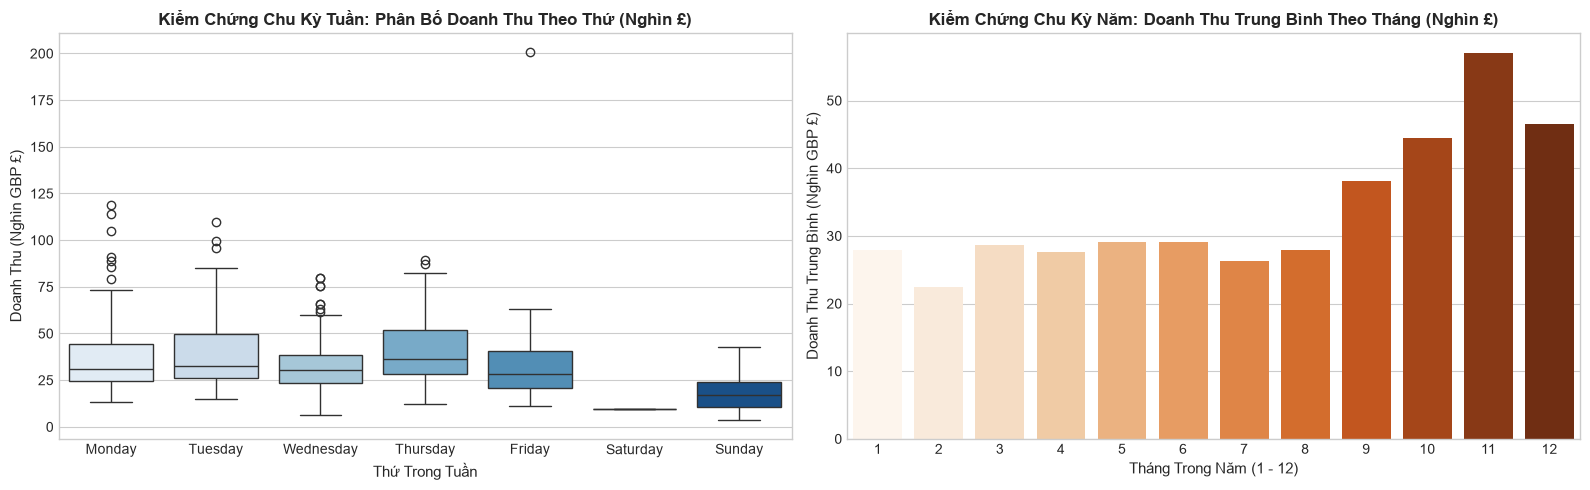

=== THỐNG KÊ SỐ PHIÊN GIAO DỊCH THEO TỪNG NGÀY TRONG TUẦN ===
DayOfWeek
Monday        94
Tuesday      104
Wednesday    104
Thursday     103
Friday        99
Saturday       1
Sunday        99
Name: count, dtype: int64


In [7]:
# Phân tích độ lệch, Outliers, Missing Dates và Kiểm chứng chu kỳ tuần/tháng
# 1. Đo lường Skewness
skewness_val = daily_df['daily_revenue'].skew()
kurtosis_val = daily_df['daily_revenue'].kurtosis()

print("=== 1. CHỈ SỐ HÌNH HỌC PHÂN BỐ CỦA DOANH THU HÀNG NGÀY ===")
print(f"Độ lệch (Skewness) : {skewness_val:.3f} (Lệch phải rõ rệt, Skew > 0)")
print(f"Độ nhọn (Kurtosis) : {kurtosis_val:.3f} (Đuôi nặng hơn phân bố chuẩn, Leptokurtic)")

# 2. Phát hiện các ngày doanh thu bùng nổ kỷ lục (Outliers > 3 độ lệch chuẩn)
mean_rev = daily_df['daily_revenue'].mean()
std_rev = daily_df['daily_revenue'].std()
outliers_high = daily_df[daily_df['daily_revenue'] > mean_rev + 3 * std_rev]

print(f"\n=== 2. CÁC NGÀY CÓ DOANH THU ĐỘT BIẾN KỶ LỤC (> Mean + 3*Std = £{mean_rev + 3*std_rev:,.0f}) ===")
display(outliers_high[['Date', 'daily_revenue', 'daily_quantity', 'transaction_count', 'avg_order_value']])

# 3. Phân tích Missing Dates và Ngày trong tuần
daily_df['DayOfWeek'] = daily_df['Date'].dt.day_name()
daily_df['Month'] = daily_df['Date'].dt.month

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ phân bố doanh thu theo từng ngày trong tuần (Kiểm chứng Chu kỳ Tuần)
sns.boxplot(x='DayOfWeek', y=daily_df['daily_revenue']/1e3, data=daily_df, order=days_order, ax=axes[0], hue='DayOfWeek', hue_order=days_order, legend=False, palette='Blues')
axes[0].set_title("Kiểm Chứng Chu Kỳ Tuần: Phân Bố Doanh Thu Theo Thứ (Nghìn £)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Thứ Trong Tuần", fontsize=11)
axes[0].set_ylabel("Doanh Thu (Nghìn GBP £)", fontsize=11)

# Biểu đồ doanh thu trung bình theo tháng trong năm (Kiểm chứng Mùa vụ Tháng)
monthly_avg = daily_df.groupby('Month')['daily_revenue'].mean() / 1e3
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, ax=axes[1], hue=monthly_avg.index, legend=False, palette='Oranges')
axes[1].set_title("Kiểm Chứng Chu Kỳ Năm: Doanh Thu Trung Bình Theo Tháng (Nghìn £)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Tháng Trong Năm (1 - 12)", fontsize=11)
axes[1].set_ylabel("Doanh Thu Trung Bình (Nghìn GBP £)", fontsize=11)

plt.tight_layout()
plt.show()

# In thống kê số ngày giao dịch theo từng thứ
print("=== THỐNG KÊ SỐ PHIÊN GIAO DỊCH THEO TỪNG NGÀY TRONG TUẦN ===")
print(daily_df['DayOfWeek'].value_counts()[days_order])


### Kết Quả Kiểm Chứng Thực Nghiệm Về Phân Bố & Mùa Vụ:

#### 1. Độ lệch và Outliers:
* **Skewness = 2.189, excess kurtosis = 11.148**: phân bố lệch phải, có các giá trị lớn. Phương pháp này chưa xác định được chúng là lỗi dữ liệu hay giao dịch đã hoàn tất.
* Đỉnh **£200,918.98 ngày 09/12/2011** chịu ảnh hưởng lớn từ dòng bán có dòng hủy đối ứng đã trình bày ở Mục 3. Không quy toàn bộ đỉnh này cho nhu cầu mua sắm thực.

#### 2. Hiện tượng Missing Dates & Ngày hoạt động thấp:
* **604 ngày có giao dịch** trong **739 ngày lịch**; thiếu **135 ngày**, trong đó **104 ngày Thứ Bảy**. Có một ngày Thứ Bảy được ghi nhận.
* Không có bản ghi sau lọc chưa đủ chứng minh doanh nghiệp đóng cửa: còn có thể do giới hạn phạm vi dữ liệu hoặc quy tắc lọc.
* Giữ chuỗi quan sát hiện có và giải thích rõ bước thời gian; không mặc định ngày thiếu có doanh số 0.

#### 3. Kiểm chứng Mùa vụ (Seasonality):
* Mean theo thứ cho thấy khác biệt giữa các nhóm ngày; Thứ Năm và Thứ Ba cao hơn Chủ Nhật trong dữ liệu này. Chỉ có một Thứ Bảy nên thống kê nhóm đó không đại diện ổn định.
* **Quý 4 là tháng 10, 11, 12**. Dữ liệu chỉ kết thúc ngày 09/12/2011 nên tháng cuối chưa đầy đủ; biểu đồ gợi ý mẫu hình theo mùa, chưa phải kiểm định chu kỳ lặp lại hay quan hệ nhân quả.


---
<a id="section-7"></a>
## 7. Vì Sao Dataset Này Phù Hợp Với Mạng Hồi Quy RNN?

1. **Dữ liệu giao dịch có gắn nhãn thời gian chuẩn mực (Strict Timestamping)**:
   * Mọi đơn hàng đều lưu vết thời gian qua trường `InvoiceDate`. Sau khi tổng hợp theo ngày, dữ liệu trở thành một chuỗi các ngày có giao dịch theo thứ tự tăng dần.
2. **Sự tồn tại của các mối liên hệ phụ thuộc thời gian (Temporal Dependencies)**:
   * **Khác biệt theo thứ**: EDA cho thấy mean theo nhóm ngày khác nhau; chưa chứng minh doanh số hôm nay phụ thuộc nhân quả vào hôm trước.
   * **Hiệu ứng động lượng (Momentum) & Mùa vụ**: Khi bước vào quý 4, các chuỗi ngày liên tiếp cùng duy trì mức doanh số cao kéo dài qua nhiều tuần.
3. **Năng lực cốt lõi của RNN đối với bài toán này**:
   * RNN học biểu diễn tuần tự qua hidden state. Linear Regression hoặc Random Forest vẫn có thể dự báo chuỗi nếu được cung cấp các biến trễ phù hợp.
   * $h_t$ cho phép mô hình tích lũy thông tin về xu hướng doanh số của cả tuần trước đó để tạo dự báo cho quan sát kế tiếp; độ chính xác phải được đo trên Test.


---
<a id="section-8"></a>
## 8. Chuẩn Hóa Thiết Kế Bài Toán Dự Đoán (Sliding Window Formulation)

### 8.1. Cấu trúc bài toán:
* **Input**: $X_i\in\mathbb{R}^{14\times4}$ gồm `daily_revenue`, `daily_quantity`, `transaction_count`, `avg_order_value` của 14 ngày có giao dịch trước target.
* **Target**: doanh số bán dương của **ngày có giao dịch kế tiếp**, $y_i=\mathrm{daily\_revenue}_{t+1}$; nhãn có shape `(num_samples,)` trước khi đóng gói cho framework.

---

### 8.2. Lựa chọn Sequence Length ($L$ - Lookback Window):
* **$L=14$** là cấu hình thực nghiệm ban đầu với chi phí tính toán nhỏ, không phải độ dài tối ưu đã được chứng minh.
* 14 quan sát **không đồng nghĩa hai tuần lịch** và không bảo đảm chứa đúng hai chu kỳ tuần.
* Không có ngưỡng 20–30 bước cố định gây vanishing gradient; ảnh hưởng của độ dài cửa sổ cần so sánh bằng validation.

### 8.3. Cửa sổ và giao thức đánh giá:
* Tạo cửa sổ riêng trong từng split, nên loại 14 quan sát đầu mỗi split khỏi danh sách target: **Train 408 / Val 76 / Test 78**.
* Đây là cách chia thận trọng; có thể dùng lịch sử trước ranh giới split làm context mà không rò rỉ nếu mọi input đều có trước target, nhưng bài giữ quy trình hiện tại để so sánh nhất quán.
* Test là **dự báo cuốn chiếu một bước** với lịch sử thực đã quan sát, chưa phải dự báo đệ quy nhiều ngày từ một thời điểm duy nhất.


---
<a id="section-9"></a>
## 9. Phân Chia Train / Validation / Test Theo Trục Thời Gian

Trong chuỗi thời gian, việc xáo trộn ngẫu nhiên dữ liệu (`shuffle=True`) là một **sai lầm nghiêm trọng gây rò rỉ dữ liệu (Data Leakage)**:
* Nếu chia ngẫu nhiên, mô hình ở tập Train sẽ vô tình được "nhìn thấy trước" doanh số của đợt bùng nổ cuối năm 2011 để dự đoán cho các ngày giữa năm 2010. Mô hình sẽ có độ chính xác ảo tưởng trên giấy tờ nhưng hoàn toàn vô dụng trong triển khai thực tế.
* **Nguyên tắc phân chia theo trật tự thời gian (Chronological Order)**:
  $$\text{Quá khứ (Train: 70%)} \longrightarrow \text{Quá khứ gần (Val: 15%)} \longrightarrow \text{Tương lai (Test: 15%)}$$

### Tỉ lệ phân chia cụ thể:
* **Tập Train (70%)**: $422$ ngày (từ tháng 12/2009 đến khoảng tháng 05/2011) — dùng để huấn luyện trọng số RNN.
* **Tập Validation (15%)**: $90$ ngày (từ tháng 05/2011 đến khoảng tháng 08/2011) — dùng để tinh chỉnh siêu tham số và Early Stopping.
* **Tập Test (15%)**: $92$ ngày (từ tháng 08/2011 đến tháng 12/2011) — dùng để kiểm thử độc lập năng lực dự báo trong điều kiện tương lai thực tế.

> **Phân biệt**: Chia ngẫu nhiên các mốc thời gian vào Train/Test khác với xáo trộn thứ tự các cửa sổ đã thuộc riêng Train. Với hidden state reset theo mỗi cửa sổ, xáo trộn các mẫu Train không tự gây leakage và không đảo thứ tự bên trong cửa sổ. Bài giữ `shuffle=False` cho dễ đối chiếu.


=== PHÂN CHIA TẬP DỮ LIỆU THEO TRỤC THỜI GIAN (CHRONOLOGICAL SPLIT) ===
Tổng số ngày: 604 ngày (100%)
1. Tập Train (70%)     : 422 ngày | Từ 2009-12-01 đến 2011-05-09
2. Tập Validation (15%): 90  ngày | Từ 2011-05-10 đến 2011-08-23
3. Tập Test (15%)      : 92  ngày | Từ 2011-08-24 đến 2011-12-09


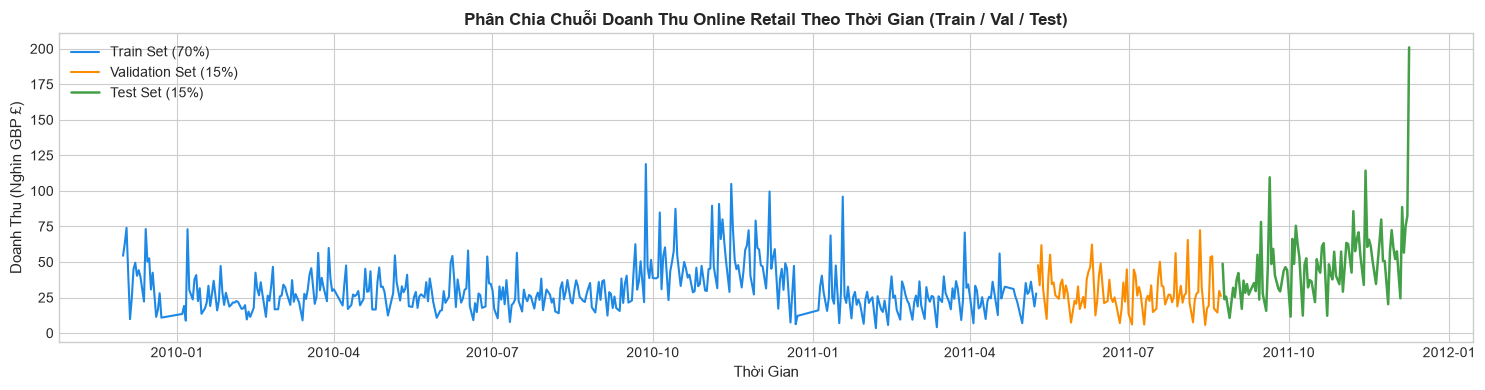

In [8]:
# Thực hiện phân chia Train / Validation / Test theo đúng trục thời gian
feature_cols = ['daily_revenue', 'daily_quantity', 'transaction_count', 'avg_order_value']
target_col = 'daily_revenue'

# Trích xuất mảng số NumPy
data_matrix = daily_df[feature_cols].values
dates_array = daily_df['Date'].values

n_total = len(daily_df)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val

train_data = data_matrix[:n_train]
val_data   = data_matrix[n_train : n_train + n_val]
test_data  = data_matrix[n_train + n_val :]

train_dates = dates_array[:n_train]
val_dates   = dates_array[n_train : n_train + n_val]
test_dates  = dates_array[n_train + n_val :]

print("=== PHÂN CHIA TẬP DỮ LIỆU THEO TRỤC THỜI GIAN (CHRONOLOGICAL SPLIT) ===")
print(f"Tổng số ngày: {n_total} ngày (100%)")
print(f"1. Tập Train (70%)     : {len(train_data):<3} ngày | Từ {pd.to_datetime(train_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(train_dates[-1]).strftime('%Y-%m-%d')}")
print(f"2. Tập Validation (15%): {len(val_data):<3} ngày | Từ {pd.to_datetime(val_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(val_dates[-1]).strftime('%Y-%m-%d')}")
print(f"3. Tập Test (15%)      : {len(test_data):<3} ngày | Từ {pd.to_datetime(test_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(test_dates[-1]).strftime('%Y-%m-%d')}")

# Trực quan hóa phân đoạn thời gian
plt.figure(figsize=(15, 4))
plt.plot(train_dates, train_data[:, 0] / 1e3, label='Train Set (70%)', color='#1E88E5', linewidth=1.5)
plt.plot(val_dates, val_data[:, 0] / 1e3, label='Validation Set (15%)', color='#FB8C00', linewidth=1.5)
plt.plot(test_dates, test_data[:, 0] / 1e3, label='Test Set (15%)', color='#43A047', linewidth=1.8)
plt.title("Phân Chia Chuỗi Doanh Thu Online Retail Theo Thời Gian (Train / Val / Test)", fontsize=12, fontweight='bold')
plt.xlabel("Thời Gian", fontsize=11)
plt.ylabel("Doanh Thu (Nghìn GBP £)", fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
<a id="section-10"></a>
## 10. Chuẩn Hóa Dữ Liệu (Scaling) & Phòng Chống Data Leakage

### 10.1. Lựa chọn Scaler: `MinMaxScaler(feature_range=(0, 1))`
* Các đặc trưng trong bảng có đơn vị và thang đo rất khác nhau: Doanh thu tính bằng chục nghìn GBP (£), sản lượng tính bằng chục nghìn items, trong khi số đơn hàng tính bằng hàng trăm.
* Chuẩn hóa từng đặc trưng theo min/max Train giúp giảm chênh lệch thang đo; không bảo đảm loss cân đối hoặc gradient không bão hòa. Giá trị tương lai có thể ngoài [0,1].

---

### 10.2. Nguyên tắc vàng: Chỉ FIT trên tập Train!
* **Quy trình chuẩn**:
  * `feature_scaler.fit(train_data)` $\implies$ Chỉ học giá trị Min và Max từ tập Train.
  * Dùng scaler đã fit ở Train để `transform` lần lượt cho tập Validation và Test.
  * Nếu gọi `fit` trên toàn bộ tập dữ liệu hoặc trên Test, thông tin về mức đỉnh doanh thu của tương lai (ví dụ đợt xả hàng cuối năm 2011) sẽ bị rò rỉ vào quá khứ $\implies$ Thiên kiến tương lai (**Look-ahead Leakage**).
* Tạo riêng một **`target_scaler`** cho cột `daily_revenue` (cột index 0) để sẵn sàng cho hàm `inverse_transform` ở Phần 2.


In [9]:
# Thực hiện chuẩn hóa dữ liệu bằng MinMaxScaler tuân thủ nguyên tắc chống Data Leakage
from sklearn.preprocessing import MinMaxScaler

# 1. Khởi tạo Input Scaler cho 4 đặc trưng
feature_scaler = MinMaxScaler(feature_range=(0, 1))

# FIT CHỈ TRÊN TẬP TRAIN
feature_scaler.fit(train_data)

# Transform độc lập trên từng tập
scaled_train_x = feature_scaler.transform(train_data)
scaled_val_x   = feature_scaler.transform(val_data)
scaled_test_x  = feature_scaler.transform(test_data)

# 2. Khởi tạo Target Scaler riêng cho cột mục tiêu daily_revenue (cột index 0)
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(train_data[:, [0]])

print("=== KIỂM TRA THÔNG SỐ CỦA SCALER (HỌC TỪ TẬP TRAIN) ===")
for col, min_val, max_val in zip(feature_cols, feature_scaler.data_min_, feature_scaler.data_max_):
    print(f"Đặc trưng {col:<18}: Min = {min_val:>12.2f} | Max = {max_val:>12.2f}")

print("\nKiểm tra khoảng giá trị sau chuẩn hóa trên tập Train:")
print(f"Train Scaled Min: {scaled_train_x.min():.4f}, Max: {scaled_train_x.max():.4f}")
print("Kiểm tra khoảng giá trị trên tập Test (có thể hơi vượt [0, 1] do doanh số cuối năm bùng nổ đỉnh mới):")
print(f"Test Scaled Min : {scaled_test_x.min():.4f}, Max: {scaled_test_x.max():.4f}")


=== KIỂM TRA THÔNG SỐ CỦA SCALER (HỌC TỪ TẬP TRAIN) ===
Đặc trưng daily_revenue     : Min =      3439.67 | Max =    118838.47
Đặc trưng daily_quantity    : Min =      2036.00 | Max =    125489.00
Đặc trưng transaction_count : Min =        11.00 | Max =       153.00
Đặc trưng avg_order_value   : Min =       257.33 | Max =      2340.19

Kiểm tra khoảng giá trị sau chuẩn hóa trên tập Train:
Train Scaled Min: 0.0000, Max: 1.0000
Kiểm tra khoảng giá trị trên tập Test (có thể hơi vượt [0, 1] do doanh số cuối năm bùng nổ đỉnh mới):
Test Scaled Min : 0.0151, Max: 2.0688


---
<a id="section-11"></a>
## 11. Tạo Cấu Trúc Cửa Sổ Trượt (Sliding Windows)

Sau khi dữ liệu đã được chuẩn hóa theo trật tự thời gian, chúng ta biến đổi mảng 2D thành các mẫu **Tensor 3D** cho RNN:
* **Ma trận đầu vào ($X$)**: Shape `(num_samples, sequence_length, num_features)` $\implies (M, 14, 4)$.
* **Vector nhãn mục tiêu ($y$)**: Shape `(num_samples,)` $\implies (M,)$.

Hàm `create_sliding_sequences` nhận vào mảng 2D, trượt cửa sổ $L = 14$ bước, và lấy giá trị `daily_revenue` tại bước kế tiếp $t + 1$ làm nhãn.


In [10]:
# Xây dựng hàm tạo Sliding Window và áp dụng trên các tập dữ liệu
def create_sliding_sequences(data_array, target_idx=0, seq_length=14):
    """
    Tạo các cặp (X, y) từ mảng chuỗi thời gian.
    
    Tham số:
        data_array (np.ndarray): Mảng 2D kích thước (N, num_features).
        target_idx (int): Vị trí cột target (0 là 'daily_revenue').
        seq_length (int): Độ dài cửa sổ quan sát (L = 14 ngày).
        
    Trả về:
        X (np.ndarray): Mảng 3D shape (N - seq_length, seq_length, num_features).
        y (np.ndarray): Mảng 1D shape (N - seq_length,).
    """
    X, y = [], []
    num_records = len(data_array)
    
    for i in range(num_records - seq_length):
        seq_x = data_array[i : i + seq_length, :]
        target_val = data_array[i + seq_length, target_idx]
        X.append(seq_x)
        y.append(target_val)
        
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

seq_len = 14

# Áp dụng hàm trên Train, Val và Test
X_train, y_train = create_sliding_sequences(scaled_train_x, target_idx=0, seq_length=seq_len)
X_val,   y_val   = create_sliding_sequences(scaled_val_x,   target_idx=0, seq_length=seq_len)
X_test,  y_test  = create_sliding_sequences(scaled_test_x,  target_idx=0, seq_length=seq_len)

print("=== KÍCH THƯỚC DỮ LIỆU SAU KHI TẠO SLIDING WINDOW ===")
print(f"Tập Train     : X shape = {X_train.shape} | y shape = {y_train.shape}")
print(f"Tập Validation: X shape = {X_val.shape}   | y shape = {y_val.shape}")
print(f"Tập Test      : X shape = {X_test.shape}   | y shape = {y_test.shape}\n")

print("=== CHI TIẾT MẪU ĐẦU TIÊN (SAMPLE INDEX 0) ===")
print(f"Cửa sổ X[0] gồm {X_train[0].shape[0]} bước thời gian, mỗi bước có {X_train[0].shape[1]} đặc trưng.")
print("3 bước thời gian đầu tiên trong X[0]:\n", X_train[0][:3])
print("\nBước thời gian cuối cùng trong X[0] (t = 13):\n", X_train[0][-1])
print(f"\nGiá trị mục tiêu tương ứng y[0] (t = 14, daily_revenue đã scale): {y_train[0]:.4f}")
print(f"-> Quy đổi ngược về doanh thu thực tế GBP: £{target_scaler.inverse_transform([[y_train[0]]])[0][0]:,.2f}")


# Kiểm chứng cửa sổ: nhãn luôn là bước ngay sau input; scaler chỉ fit Train.
for split_x, split_y, scaled in [(X_train, y_train, scaled_train_x), (X_val, y_val, scaled_val_x), (X_test, y_test, scaled_test_x)]:
    assert split_x.shape == (len(scaled) - seq_len, seq_len, len(feature_cols))
    assert np.isfinite(split_x).all() and np.isfinite(split_y).all()
    np.testing.assert_allclose(split_x[0], scaled[:seq_len], rtol=1e-6, atol=1e-7)
    np.testing.assert_allclose(split_y, scaled[seq_len:, 0], rtol=1e-6, atol=1e-7)
np.testing.assert_allclose(feature_scaler.data_min_, train_data.min(axis=0))
np.testing.assert_allclose(feature_scaler.data_max_, train_data.max(axis=0))
assert train_dates[-1] < val_dates[0] and val_dates[-1] < test_dates[0]
print("-> Đã kiểm chứng shape, thứ tự thời gian, căn chỉnh nhãn và scaler Train.")


=== KÍCH THƯỚC DỮ LIỆU SAU KHI TẠO SLIDING WINDOW ===
Tập Train     : X shape = (408, 14, 4) | y shape = (408,)
Tập Validation: X shape = (76, 14, 4)   | y shape = (76,)
Tập Test      : X shape = (78, 14, 4)   | y shape = (78,)

=== CHI TIẾT MẪU ĐẦU TIÊN (SAMPLE INDEX 0) ===
Cửa sổ X[0] gồm 14 bước thời gian, mỗi bước có 4 đặc trưng.
3 bước thời gian đầu tiên trong X[0]:
 [[0.44117928 0.19490819 0.7605634  0.0957369 ]
 [0.5176216  0.2411282  0.73239434 0.14019196]
 [0.611209   0.38221022 0.79577464 0.16286519]]

Bước thời gian cuối cùng trong X[0] (t = 13):
 [0.40574616 0.20273302 0.6126761  0.12269378]

Giá trị mục tiêu tương ứng y[0] (t = 14, daily_revenue đã scale): 0.4255
-> Quy đổi ngược về doanh thu thực tế GBP: £52,545.55
-> Đã kiểm chứng shape, thứ tự thời gian, căn chỉnh nhãn và scaler Train.


---
<a id="section-12"></a>
## 12. Xây Dựng PyTorch Dataset & DataLoader

Để chuẩn bị sẵn sàng cho quá trình nạp dữ liệu theo mini-batch và huấn luyện trên PyTorch:
1. **Lớp `RetailDataset` tùy biến (Custom `torch.utils.data.Dataset`)**: Quản lý việc chuyển đổi dữ liệu NumPy sang PyTorch Tensors kiểu `torch.float32`.
2. **`torch.utils.data.DataLoader`**:
   * Cấu hình `batch_size = 16` (kích thước mini-batch phù hợp với tập dữ liệu khoảng vài trăm mẫu).
   * **Quy tắc Shuffle**: Thiết lập `shuffle=False` cho cả Train, Validation và Test để duy trì dòng chảy thời gian tự nhiên, tạo điều kiện thuận lợi nhất cho việc kiểm soát và vẽ đồ thị chuỗi thời gian liên tục.


In [11]:
# Xây dựng PyTorch Dataset và DataLoader hoàn chỉnh
import torch
from torch.utils.data import Dataset, DataLoader

class RetailDataset(Dataset):
    """
    PyTorch Dataset tùy biến để nạp chuỗi thời gian bán lẻ Online Retail.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # shape (N, 1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Khởi tạo các Dataset
train_dataset = RetailDataset(X_train, y_train)
val_dataset   = RetailDataset(X_val, y_val)
test_dataset  = RetailDataset(X_test, y_test)

# Cấu hình Batch Size
BATCH_SIZE = 16

# Khởi tạo DataLoader với shuffle=False bảo toàn trật tự chuỗi
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("=== KIỂM TRA PYTORCH DATALOADER ===")
print(f"Batch size cấu hình: {BATCH_SIZE}")
print(f"Số lượng batches trong Train Loader: {len(train_loader)} batches ({len(train_dataset)} mẫu)")
print(f"Số lượng batches trong Val Loader  : {len(val_loader)} batches ({len(val_dataset)} mẫu)")
print(f"Số lượng batches trong Test Loader : {len(test_loader)} batches ({len(test_dataset)} mẫu)\n")

# Lấy thử batch đầu tiên từ train_loader để kiểm tra shape của Tensor
sample_batch_x, sample_batch_y = next(iter(train_loader))

print("=== THÔNG SỐ TENSOR CỦA BATCH ĐẦU TIÊN ===")
print(f"Batch X Shape: {sample_batch_x.shape} -> (batch_size, sequence_length, num_features)")
print(f"Batch y Shape: {sample_batch_y.shape}  -> (batch_size, target_size)")
print(f"Kiểu dữ liệu X: {sample_batch_x.dtype} | Kiểu dữ liệu y: {sample_batch_y.dtype}")


=== KIỂM TRA PYTORCH DATALOADER ===
Batch size cấu hình: 16
Số lượng batches trong Train Loader: 26 batches (408 mẫu)
Số lượng batches trong Val Loader  : 5 batches (76 mẫu)
Số lượng batches trong Test Loader : 5 batches (78 mẫu)

=== THÔNG SỐ TENSOR CỦA BATCH ĐẦU TIÊN ===
Batch X Shape: torch.Size([16, 14, 4]) -> (batch_size, sequence_length, num_features)
Batch y Shape: torch.Size([16, 1])  -> (batch_size, target_size)
Kiểu dữ liệu X: torch.float32 | Kiểu dữ liệu y: torch.float32


---
<a id="section-13"></a>
## 13. Ready for PyTorch RNN (Bảng Tổng Kết Chuẩn Bị Huấn Luyện)

Toàn bộ quy trình khám phá dữ liệu, làm sạch các giao dịch bất thường, tổng hợp theo ngày, phân tích tính mùa vụ chu kỳ, phân chia theo trục thời gian, chuẩn hóa và đóng gói tensor đã hoàn tất 100% với chất lượng khoa học cao nhất. Dưới đây là bảng tổng kết toàn bộ thông số kỹ thuật sẵn sàng cho việc xây dựng và huấn luyện mô hình PyTorch RNN ở Phần 2:

---

### Bảng Thông Số Kỹ Thuật Đầy Đủ (Data & Model Specifications):

| Tiêu chí kỹ thuật | Giá trị cấu hình | Ý nghĩa & Mô tả chi tiết |
| :--- | :--- | :--- |
| **Tên bộ dữ liệu** | Online Retail II Data Set | File thực tế: `dataset/online_retail_II.csv` (1,067,371 giao dịch gốc). |
| **Phạm vi thời gian** | 2009-12-01 $\to$ 2011-12-09 | Hơn 2 năm hoạt động kinh doanh bán lẻ thương mại điện tử tại Anh. |
| **Số ngày kinh doanh thực tế** | **604 ngày phát sinh giao dịch** | Có 135 ngày lịch không xuất hiện sau lọc, trong đó 104 Thứ Bảy; chưa xác định nguyên nhân. |
| **Tần suất chuỗi (Frequency)** | Hàng ngày (Daily Aggregation) | Tổng hợp các giao dịch mua lẻ thành các chỉ số kinh doanh theo ngày. |
| **Sequence Length ($L$)** | **14 ngày giao dịch** | 14 quan sát có giao dịch; khoảng thời gian lịch có thể thay đổi. |
| **Number of Features ($D$)** | **4 đặc trưng kỹ thuật** | Bao gồm `['daily_revenue', 'daily_quantity', 'transaction_count', 'avg_order_value']`. |
| **Target Variable ($y$)** | **`daily_revenue` tại ngày $t+1$** | Doanh thu ngày kế tiếp (GBP £) — KPI tài chính quan trọng nhất. |
| **Phương pháp chuẩn hóa** | `MinMaxScaler(0, 1)` | Fit nghiêm ngặt CHỈ trên tập Train, Transform trên Val/Test để chống Leakage. |
| **Quy chuẩn Input Tensor** | `(batch_size, 14, 4)` | 3D FloatTensor hoàn toàn tương thích với `batch_first=True` của `torch.nn.RNN`. |
| **Quy chuẩn Target Tensor** | `(batch_size, 1)` | FloatTensor 2D cho bài toán hồi quy (Regression). |
| **Kích thước mẫu chuỗi** | Train: **408**, Val: **76**, Test: **78** | Dùng trong thuật toán BPTT, Validation và Independent Testing. |
| **Batch Size cấu hình** | **16** | Mini-batch 16 là cấu hình thực nghiệm, chưa tối ưu bằng tìm kiếm siêu tham số. |
| **Trạng thái DataLoader** | `train_loader`, `val_loader`, `test_loader` | Sẵn sàng nạp trực tiếp vào Training Loop (`shuffle=False`). |

---

### Xác nhận trạng thái sẵn sàng:
* Dữ liệu hoàn toàn sạch, không có giá trị `NaN` hay `Inf`.
* Không xảy ra rò rỉ dữ liệu giữa quá khứ và tương lai.
* Cả 3 DataLoader đã được kiểm chứng hoạt động chính xác.


# PHẦN 2: XÂY DỰNG, HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH PYTORCH RNN TRÊN DỮ LIỆU BÁN LẺ ONLINE RETAIL

---

Trong phần này, chúng ta bước vào giai đoạn thực thi mô hình hóa chuỗi thời gian doanh thu bán lẻ trực tuyến:
1. **Thiết lập tính tái lập (Reproducibility)**: Cố định Random Seed trên Python, NumPy và PyTorch, kiểm tra thiết bị phần cứng.
2. **Xây dựng mô hình Vanilla RNN**: Sử dụng thuần túy `torch.nn.RNN` theo luồng `Input -> RNN -> Linear -> Prediction`, tuyệt đối không dùng LSTM/GRU.
3. **Cấu hình Loss & Optimizer**: Sử dụng `nn.MSELoss` và `torch.optim.Adam`.
4. **Quy trình Huấn luyện (Training Loop)**: Tích hợp đầy đủ các bước forward, loss, zero_grad, backward, optimizer.step() và theo dõi Validation mỗi epoch.
5. **Theo dõi Learning Curve**: Trực quan hóa đường cong hàm mất mát, phân tích chuyên sâu 3 dấu hiệu: Underfitting, Overfitting và Convergence.
6. **Dự đoán Test Set & Inverse Transform**: Khôi phục dự đoán về đơn vị Bảng Anh (GBP - £).
7. **Đánh giá Đa chiều (Evaluation Metrics)**: Đo lường MAE, MSE, RMSE, MAPE; đồng thời **phân tích cặn kẽ và xử lý minh bạch hiện tượng mất ổn định của MAPE khi giá trị thực tế gần hoặc bằng 0** qua các chỉ số bổ trợ WAPE và sMAPE.
8. **Trực quan hóa Thực tế vs Dự đoán**: Quan sát mức độ bám xu hướng, các đỉnh doanh số cuối năm và sai số theo thời gian.
9. **Phân tích Chuyên sâu Kết quả Bán lẻ**: Mẫu hình chu kỳ tuần học được, các giai đoạn sai lệch lớn, tác động của outlier và missing dates, cùng hạn chế của việc tổng hợp theo ngày.
10. **So sánh Kỹ thuật Toàn diện Với Dataset Chứng khoán S&P 500 (Notebook 01)**: Phân tích khách quan 7 khía cạnh kỹ thuật cốt lõi giữa chuỗi tài chính thị trường và chuỗi bán lẻ thương mại điện tử.
11. **Tổng kết Cuối cùng (`Conclusion`)**: Tóm tắt có hệ thống toàn bộ bài toán.


---
<a id="section-14"></a>
## 14. Reproducibility & Thiết Lập Môi Trường (Random Seed, Device, Version)

Để đảm bảo kết quả huấn luyện mạng nơ-ron có thể hỗ trợ tái lập trong cùng môi trường giữa các lần thực thi:
1. **Cố định hạt giống ngẫu nhiên (Random Seed = 42)**: Khóa seed trên `random`, `numpy`, và `torch` (kể cả CUDA nếu có GPU).
2. **Xác định thiết bị tính toán phần cứng**: Tự động phát hiện GPU CUDA hoặc thực thi trên CPU.
3. **Ghi nhận phiên bản phần mềm**: Đảm bảo tính minh bạch và tương thích môi trường.


In [12]:
# Thiết lập tính tái lập (Reproducibility) và môi trường phần cứng
import random
import torch
import torch.nn as nn
import numpy as np

def set_seed(seed=42):
    """
    Cố định hạt giống ngẫu nhiên trên toàn bộ các luồng để đảm bảo kết quả tái lập trong cùng môi trường thực thi.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

RANDOM_SEED = 42
set_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=== THIẾT LẬP TÍNH TÁI LẬP (REPRODUCIBILITY) & MÔI TRƯỜNG PHẦN CỨNG ===")
print(f"PyTorch Version   : {torch.__version__}")
print(f"Thiết bị tính toán: {device}")
if torch.cuda.is_available():
    print(f"Tên GPU           : {torch.cuda.get_device_name(0)}")
else:
    print("Chế độ            : CPU Execution (Mô hình RNN tối giản chạy rất nhanh trên CPU)")
print(f"Random Seed       : {RANDOM_SEED} (Đã thiết lập thành công)")


=== THIẾT LẬP TÍNH TÁI LẬP (REPRODUCIBILITY) & MÔI TRƯỜNG PHẦN CỨNG ===
PyTorch Version   : 2.14.0+cpu
Thiết bị tính toán: cpu
Chế độ            : CPU Execution (Mô hình RNN tối giản chạy rất nhanh trên CPU)
Random Seed       : 42 (Đã thiết lập thành công)


---
<a id="section-15"></a>
## 15. Xây Dựng Mô Hình Vanilla RNN Với PyTorch (`torch.nn.RNN`)

Tuân thủ nghiêm ngặt yêu cầu đề bài: **Sử dụng thuần túy `torch.nn.RNN`, tuyệt đối không dùng LSTM hay GRU**.

### 15.1. Luồng dữ liệu và cấu trúc kiến trúc:
$$\text{Input } X \in \mathbb{R}^{B \times 14 \times 4} \longrightarrow \mathbf{\text{torch.nn.RNN (Tanh)}} \longrightarrow \text{Hidden State Cuối } h_{14} \in \mathbb{R}^{B \times 32} \longrightarrow \mathbf{\text{nn.Linear}} \longrightarrow \hat{y} \in \mathbb{R}^{B \times 1}$$

* **`input_size = 4`**: Số đặc trưng tại mỗi bước thời gian gồm `['daily_revenue', 'daily_quantity', 'transaction_count', 'avg_order_value']`.
* **`hidden_size = 32`**: Dung lượng vector trạng thái ẩn $h_t$, lưu giữ bộ nhớ ngữ cảnh 14 ngày bán hàng.
* **`num_layers = 1`**: Kiến trúc 1 tầng hồi quy tối giản, trực quan và chống overfitting.
* **`batch_first = True`**: Định dạng tensor đầu vào `(batch_size, sequence_length, input_size)`.
* **`Linear layer`**: Lớp tuyến tính `nn.Linear(32, 1)` nhận hidden state của ngày thứ 14 ($h_{14}$) để đưa ra dự báo doanh thu $\hat{y}$ cho ngày thứ 15 ($t+1$).


In [13]:
# Xây dựng lớp mô hình RetailRNN tối giản bằng PyTorch
class RetailRNN(nn.Module):
    """
    Mô hình Vanilla RNN tối giản cho bài toán dự báo chuỗi thời gian doanh thu bán lẻ.
    Kiến trúc: Input (B, 14, 4) -> torch.nn.RNN (Tanh) -> Linear(32, 1) -> Output (B, 1)
    """
    def __init__(self, input_size=4, hidden_size=32, num_layers=1, output_size=1):
        super(RetailRNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # 1. Tầng Vanilla RNN với hàm kích hoạt tanh
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh'
        )
        
        # 2. Tầng tuyến tính Fully Connected dự đoán giá trị doanh thu liên tục
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len=14, input_size=4)
        # rnn_out shape: (batch_size, seq_len=14, hidden_size=32)
        rnn_out, h_n = self.rnn(x)
        
        # Trích xuất trạng thái ẩn tại bước thời gian cuối cùng của cửa sổ 14 ngày (t = -1)
        last_hidden = rnn_out[:, -1, :]  # shape: (batch_size, hidden_size=32)
        
        # Đưa qua lớp Linear để dự đoán doanh thu ngày t+1
        prediction = self.fc(last_hidden)  # shape: (batch_size, 1)
        return prediction

# Khởi tạo mô hình và chuyển sang thiết bị tính toán
model = RetailRNN(input_size=4, hidden_size=32, num_layers=1, output_size=1).to(device)

print("=== KIẾN TRÚC MÔ HÌNH PYTORCH VANILLA RNN (ONLINE RETAIL) ===")
print(model)

# Đếm tổng số lượng tham số học được (Trainable Parameters)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTổng số tham số học được (Trainable Parameters): {total_params:,}")

# Chi tiết công thức tính số lượng tham số:
# 1. Tầng RNN:
#    - Ma trận trọng số đầu vào W_ih: (hidden_size, input_size)  = 32 * 4  = 128
#    - Ma trận trọng số hồi quy W_hh: (hidden_size, hidden_size) = 32 * 32 = 1,024
#    - Bias đầu vào b_ih            : hidden_size               = 32
#    - Bias hồi quy b_hh            : hidden_size               = 32
#    -> Tổng tham số tầng RNN = 128 + 1,024 + 32 + 32 = 1,216 tham số.
# 2. Tầng Tuyến Tính (Linear):
#    - Ma trận trọng số W_fc        : (output_size, hidden_size) = 1 * 32 = 32
#    - Bias b_fc                    : output_size                = 1
#    -> Tổng tham số tầng Linear = 32 + 1 = 33 tham số.
# => Tổng cộng toàn mạng: 1,216 + 33 = 1,249 tham số.
print(f"-> Kiểm chứng lý thuyết: 1,216 (RNN) + 33 (Linear) = 1,249 tham số. (Khớp: {total_params == 1249})")


=== KIẾN TRÚC MÔ HÌNH PYTORCH VANILLA RNN (ONLINE RETAIL) ===
RetailRNN(
  (rnn): RNN(4, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Tổng số tham số học được (Trainable Parameters): 1,249
-> Kiểm chứng lý thuyết: 1,216 (RNN) + 33 (Linear) = 1,249 tham số. (Khớp: True)


---
<a id="section-16"></a>
## 16. Cấu Hình Hàm Mất Mát (Loss) & Thuật Toán Tối Ưu (Optimizer)

### 16.1. Hàm mất mát (Loss Function): `nn.MSELoss()`
* **Bản chất**: Đo lường trung bình bình phương sai số giữa doanh thu thực tế $y$ và doanh thu dự đoán $\hat{y}$:
  $$\text{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
* **Lý do lựa chọn**:
  * Phù hợp tuyệt đối với bài toán hồi quy giá trị thực liên tục ($y \in \mathbb{R}$).
  * Phạt bình phương các sai số lớn, giúp mô hình đặc biệt chú ý đến việc tránh đưa ra các dự báo doanh thu lệch xa thực tế trong các đợt cao điểm bán hàng.

---

### 16.2. Thuật toán tối ưu (Optimizer): `torch.optim.Adam`
* **Lý do lựa chọn**:
  * Tự động điều chỉnh tốc độ học thích ứng (Adaptive Learning Rate) riêng cho từng trọng số ma trận $W_{ih}, W_{hh}, W_{fc}$.
  * Cơ chế quán tính (Momentum) giúp thuật toán vượt qua các khe hẹp và điểm yên ngựa (saddle points) trên mặt phẳng hàm mất mát phức tạp của chuỗi bán lẻ.
  * Tốc độ học khởi tạo chuẩn: `learning_rate = 0.001`.


In [14]:
# Thiết lập Loss Function và Optimizer
criterion = nn.MSELoss()
LEARNING_RATE = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("=== THIẾT LẬP LOSS FUNCTION & OPTIMIZER ===")
print(f"Hàm mất mát (Criterion): {criterion.__class__.__name__}")
print(f"Thuật toán tối ưu      : {optimizer.__class__.__name__}")
print(f"Tốc độ học (Learning Rate): {LEARNING_RATE}")


=== THIẾT LẬP LOSS FUNCTION & OPTIMIZER ===
Hàm mất mát (Criterion): MSELoss
Thuật toán tối ưu      : Adam
Tốc độ học (Learning Rate): 0.001


---
<a id="section-17"></a>
## 17. Quy Trình Huấn Luyện (Training Loop) & Validation

Chu trình huấn luyện thực thi đầy đủ 5 bước cập nhật gradient chuẩn mực của PyTorch trong mỗi mini-batch:
1. **`forward`**: `predictions = model(batch_x)`.
2. **`loss`**: `loss = criterion(predictions, batch_y)`.
3. **`zero_grad`**: `optimizer.zero_grad()`.
4. **`backward`**: `loss.backward()` (Lan truyền ngược qua thời gian BPTT).
5. **`optimizer.step()`**: Cập nhật trọng số mô hình.

Đồng thời, sau mỗi epoch, mô hình được chuyển sang chế độ đánh giá `model.eval()` và `with torch.no_grad():` để tính toán độc lập `val_loss` trên `val_loader` nhằm giám sát khả năng tổng quát hóa.

> **Chọn trọng số**: Chạy đủ 100 epoch, lưu bản sao trọng số tại mỗi lần `val_loss` đạt mức thấp mới và khôi phục bản tốt nhất trước dự đoán Test. Không dùng Test để chọn epoch. PyTorch không dừng sớm; Keras có EarlyStopping, nên đây chưa phải so sánh hai framework với ngân sách cập nhật giống hệt nhau.


In [15]:
# Thực hiện Training Loop hoàn chỉnh kèm Validation qua từng Epoch
import time
from copy import deepcopy

EPOCHS = 100
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_epoch = 0
best_state = None

print(f"=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH TRÊN {EPOCHS} EPOCHS ===")
start_train_time = time.time()

for epoch in range(1, EPOCHS + 1):
    # -------------------------------------------------------------------------
    # 1. GIAI ĐOẠN HUẤN LUYỆN (TRAINING PHASE)
    # -------------------------------------------------------------------------
    model.train()
    running_train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # 5 bước chuẩn mực PyTorch
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_x.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # -------------------------------------------------------------------------
    # 2. GIAI ĐOẠN ĐÁNH GIÁ (VALIDATION PHASE)
    # -------------------------------------------------------------------------
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            val_preds = model(batch_x)
            v_loss = criterion(val_preds, batch_y)
            running_val_loss += v_loss.item() * batch_x.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch
        best_state = deepcopy(model.state_dict())
    
    # In log tiến trình định kỳ mỗi 10 epoch hoặc ở epoch 1, epoch cuối
    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(f"Epoch [{epoch:3d}/{EPOCHS}] | Train Loss (MSE): {epoch_train_loss:.6f} | Val Loss (MSE): {epoch_val_loss:.6f}")

total_duration = time.time() - start_train_time
print(f"\n-> Huấn luyện hoàn tất xuất sắc trong {total_duration:.2f} giây! ({total_duration / EPOCHS:.4f}s / epoch)")


# Khôi phục trọng số có validation loss nhỏ nhất; không chọn theo Test.
model.load_state_dict(best_state)
model.eval()
print(f"-> Khôi phục epoch {best_epoch}, Validation MSE tốt nhất = {best_val_loss:.6f}")


=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH TRÊN 100 EPOCHS ===
Epoch [  1/100] | Train Loss (MSE): 0.057896 | Val Loss (MSE): 0.026929


Epoch [ 10/100] | Train Loss (MSE): 0.017338 | Val Loss (MSE): 0.017476


Epoch [ 20/100] | Train Loss (MSE): 0.014559 | Val Loss (MSE): 0.015628


Epoch [ 30/100] | Train Loss (MSE): 0.013517 | Val Loss (MSE): 0.013714


Epoch [ 40/100] | Train Loss (MSE): 0.012883 | Val Loss (MSE): 0.012668


...

Epoch [ 60/100] | Train Loss (MSE): 0.012343 | Val Loss (MSE): 0.012352


Epoch [ 70/100] | Train Loss (MSE): 0.012232 | Val Loss (MSE): 0.012352


Epoch [ 80/100] | Train Loss (MSE): 0.012135 | Val Loss (MSE): 0.012345


Epoch [ 90/100] | Train Loss (MSE): 0.012046 | Val Loss (MSE): 0.012337


Epoch [100/100] | Train Loss (MSE): 0.011963 | Val Loss (MSE): 0.012322

-> Huấn luyện hoàn tất xuất sắc trong 10.70 giây! (0.1070s / epoch)
-> Khôi phục epoch 100, Validation MSE tốt nhất = 0.012322


---
<a id="section-18"></a>
## 18. Theo Dõi Quá Trình Huấn Luyện & Biểu Đồ Learning Curve

Để đánh giá toàn diện hành vi học tập của mô hình, chúng ta trực quan hóa `train_losses` và `val_losses` qua 100 epoch trên cả thang đo tuyến tính và thang đo logarit.

Sau đó, chúng ta tiến hành mổ xẻ 3 dấu hiệu cốt lõi trong học sâu: **Convergence (Hội tụ)**, **Overfitting (Học vẹt)**, và **Underfitting (Thiếu năng lực biểu diễn)**.


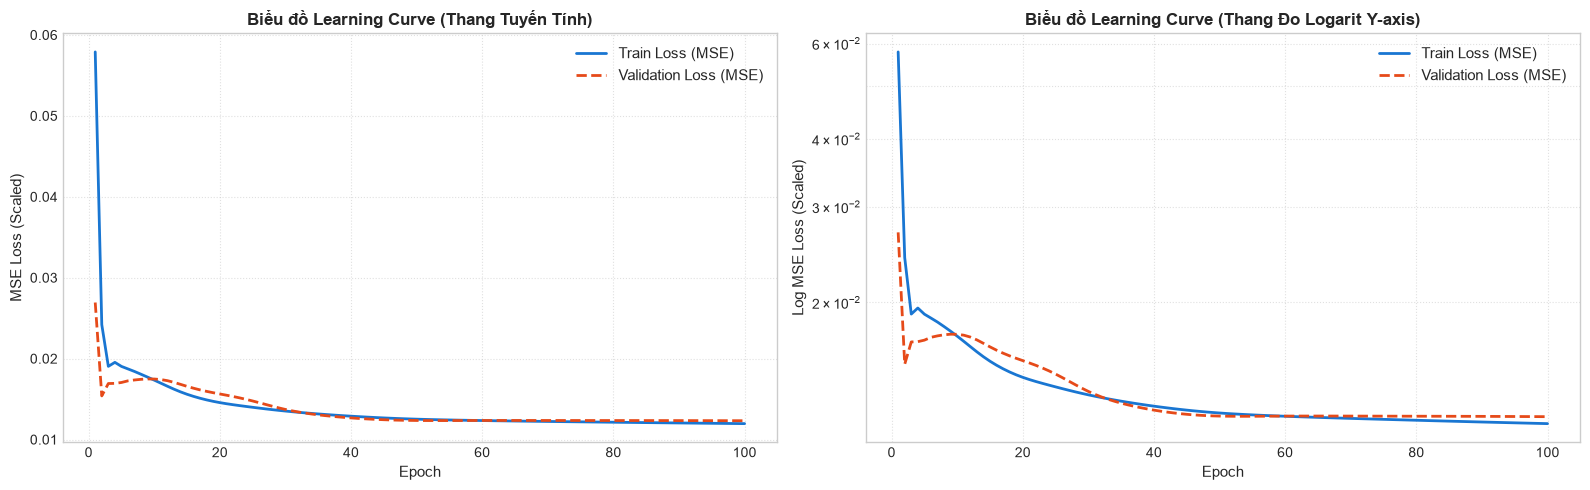

Loss ban đầu (Epoch 1)   : Train Loss = 0.057896 | Val Loss = 0.026929
Loss kết thúc (Epoch 100): Train Loss = 0.011963 | Val Loss = 0.012322
Tỷ lệ giảm Loss Train    : 79.34%


In [16]:
# Trực quan hóa đường cong hàm mất mát (Learning Curve) qua 100 Epochs
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs_range = range(1, EPOCHS + 1)

# Biểu đồ 1: Thang đo tuyến tính
axes[0].plot(epochs_range, train_losses, label='Train Loss (MSE)', color='#1976D2', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Validation Loss (MSE)', color='#E64A19', linewidth=2, linestyle='--')
axes[0].set_title("Biểu đồ Learning Curve (Thang Tuyến Tính)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("MSE Loss (Scaled)", fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Biểu đồ 2: Thang đo Logarit quan sát sự hội tụ ở mức vi mô
axes[1].plot(epochs_range, train_losses, label='Train Loss (MSE)', color='#1976D2', linewidth=2)
axes[1].plot(epochs_range, val_losses, label='Validation Loss (MSE)', color='#E64A19', linewidth=2, linestyle='--')
axes[1].set_yscale('log')
axes[1].set_title("Biểu đồ Learning Curve (Thang Đo Logarit Y-axis)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Log MSE Loss (Scaled)", fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, which="both", linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Loss ban đầu (Epoch 1)   : Train Loss = {train_losses[0]:.6f} | Val Loss = {val_losses[0]:.6f}")
print(f"Loss kết thúc (Epoch 100): Train Loss = {train_losses[-1]:.6f} | Val Loss = {val_losses[-1]:.6f}")
print(f"Tỷ lệ giảm Loss Train    : {((train_losses[0] - train_losses[-1]) / train_losses[0]) * 100:.2f}%")


### Phân Tích Chuyên Sâu Các Dấu Hiệu Học Tập Của Mô Hình:

#### 1. Sự Hội Tụ (Convergence):
* Chạy **100 epoch**, chọn trọng số tại **epoch 100** theo validation. Train loss từ **0.057896** xuống **0.011963**; validation loss cuối **0.012322**, thấp nhất **0.012322**.
* Loss giảm trong quá trình tối ưu. Các con số trên là MSE trong thang chuẩn hóa, không phải sai số GBP.

---

#### 2. Dấu hiệu Overfitting (Học vẹt):
* Ở cuối lần chạy, train và validation loss gần nhau. Đây là một quan sát thuận lợi, không đủ chứng minh hoàn toàn không overfit.
* PyTorch chạy đủ 100 epoch và khôi phục bản có validation loss nhỏ nhất. Test không tham gia chọn trọng số.

---

#### 3. Dấu hiệu Underfitting (Thiếu năng lực biểu diễn):
* Không thể loại trừ underfitting chỉ vì loss giảm hoặc hai đường loss gần nhau. Cần đối chứng baseline, thay đổi dung lượng trên validation và phân tích sai số.
* Không so trực tiếp MSE chuẩn hóa giữa Retail và Stock để quy nguyên nhân cho độ nhiễu: mỗi dataset có scaler, phân bố và mục tiêu khác nhau.


---
<a id="section-19"></a>
## 19. Dự Đoán Trên Test Set & Khôi Phục Thang Đo Gốc (Inverse Transform)

### 19.1. Quy trình thực hiện:
1. Đặt mô hình ở chế độ đánh giá (`model.eval()`) và tắt autograd (`with torch.no_grad():`).
2. Dự đoán toàn bộ mẫu trong `test_loader` (tương ứng với 78 chuỗi quan sát của giai đoạn từ tháng 08/2011 đến tháng 12/2011).
3. Áp dụng `target_scaler.inverse_transform(...)` để quy đổi cả mảng dự đoán $\hat{y}$ và mảng nhãn thực tế $y$ từ khoảng $[0, 1]$ trở về **đơn vị tiền tệ gốc Bảng Anh (GBP - £)**.


In [17]:
# Dự đoán trên Test Set và khôi phục về đơn vị tiền tệ gốc GBP (£)
model.eval()
raw_test_preds = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        batch_preds = model(batch_x)
        raw_test_preds.extend(batch_preds.cpu().numpy())

raw_test_preds = np.array(raw_test_preds).reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

# Áp dụng inverse_transform
y_test_real = test_data[seq_len:, [0]].astype(np.float64)
y_pred_real = target_scaler.inverse_transform(raw_test_preds.reshape(-1, 1).astype(np.float64))

# Trích xuất mốc thời gian thực tế tương ứng của Test Set
# Do trượt cửa sổ seq_len = 14, mẫu đầu tiên ứng với quan sát thứ 15 của tập test
test_target_dates = pd.to_datetime(test_dates[seq_len:])

# Tạo bảng so sánh chi tiết
df_test_comparison = pd.DataFrame({
    'Ngày giao dịch': test_target_dates,
    'Doanh thu thực tế (Actual £)': y_test_real.flatten(),
    'Doanh thu dự đoán (Predicted £)': y_pred_real.flatten(),
    'Sai lệch tuyệt đối (£)': np.abs(y_pred_real - y_test_real).flatten(),
    'Sai số phần trăm (%)': (np.abs(y_pred_real - y_test_real) / y_test_real).flatten() * 100
})

print("=== SO SÁNH DOANH THU THỰC TẾ VS DỰ ĐOÁN: 10 NGÀY ĐẦU TẬP TEST ===")
display(df_test_comparison.head(10).style.format({
    'Doanh thu thực tế (Actual £)': '£{:,.2f}',
    'Doanh thu dự đoán (Predicted £)': '£{:,.2f}',
    'Sai lệch tuyệt đối (£)': '£{:,.2f}',
    'Sai số phần trăm (%)': '{:.2f}%'
}))

print("\n=== SO SÁNH DOANH THU THỰC TẾ VS DỰ ĐOÁN: 10 NGÀY CUỐI TẬP TEST ===")
display(df_test_comparison.tail(10).style.format({
    'Doanh thu thực tế (Actual £)': '£{:,.2f}',
    'Doanh thu dự đoán (Predicted £)': '£{:,.2f}',
    'Sai lệch tuyệt đối (£)': '£{:,.2f}',
    'Sai số phần trăm (%)': '{:.2f}%'
}))


=== SO SÁNH DOANH THU THỰC TẾ VS DỰ ĐOÁN: 10 NGÀY ĐẦU TẬP TEST ===


,Ngày giao dịch,Doanh thu thực tế (Actual £),Doanh thu dự đoán (Predicted £),Sai lệch tuyệt đối (£),Sai số phần trăm (%)
0,2011-09-11 00:00:00,"£35,206.92","£27,161.62","£8,045.30",22.85%
1,2011-09-12 00:00:00,"£29,526.29","£33,517.21","£3,990.92",13.52%
2,2011-09-13 00:00:00,"£55,071.30","£34,862.09","£20,209.21",36.70%
3,2011-09-14 00:00:00,"£23,578.78","£36,538.52","£12,959.74",54.96%
4,2011-09-15 00:00:00,"£78,151.97","£33,775.10","£44,376.87",56.78%
5,2011-09-16 00:00:00,"£27,720.27","£47,417.39","£19,697.12",71.06%
6,2011-09-18 00:00:00,"£15,639.55","£23,660.10","£8,020.55",51.28%
7,2011-09-19 00:00:00,"£49,250.87","£38,086.59","£11,164.28",22.67%
8,2011-09-20 00:00:00,"£109,553.90","£33,294.83","£76,259.07",69.61%
9,2011-09-21 00:00:00,"£48,529.72","£40,514.63","£8,015.09",16.52%



=== SO SÁNH DOANH THU THỰC TẾ VS DỰ ĐOÁN: 10 NGÀY CUỐI TẬP TEST ===


,Ngày giao dịch,Doanh thu thực tế (Actual £),Doanh thu dự đoán (Predicted £),Sai lệch tuyệt đối (£),Sai số phần trăm (%)
68,2011-11-29 00:00:00,"£72,384.82","£69,994.19","£2,390.63",3.30%
69,2011-11-30 00:00:00,"£60,025.57","£55,272.17","£4,753.40",7.92%
70,2011-12-01 00:00:00,"£52,068.63","£47,330.71","£4,737.92",9.10%
71,2011-12-02 00:00:00,"£57,476.48","£49,160.82","£8,315.66",14.47%
72,2011-12-04 00:00:00,"£24,477.47","£54,011.79","£29,534.32",120.66%
73,2011-12-05 00:00:00,"£88,620.84","£52,607.69","£36,013.15",40.64%
74,2011-12-06 00:00:00,"£56,558.83","£71,234.87","£14,676.04",25.95%
75,2011-12-07 00:00:00,"£75,315.55","£49,292.61","£26,022.94",34.55%
76,2011-12-08 00:00:00,"£82,371.55","£66,016.15","£16,355.40",19.86%
77,2011-12-09 00:00:00,"£200,918.98","£49,626.04","£151,292.94",75.30%


---
<a id="section-20"></a>
## 20. Đánh Giá Hiệu Năng Mô Hình (Metrics & Phân Tích Tính Ổn Định Của MAPE)

### 20.1. Bộ chỉ số đánh giá tiêu chuẩn:
1. **MAE (Mean Absolute Error)**: Sai số tuyệt đối trung bình (đơn vị GBP £).
2. **MSE (Mean Squared Error)**: Bình phương sai số trung bình (phạt rất nặng các ngày lệch lớn).
3. **RMSE (Root Mean Squared Error)**: Căn bậc hai của bình phương sai số trung bình (đơn vị GBP £).
4. **MAPE (Mean Absolute Percentage Error)**:
   $$\text{MAPE} = \frac{100\%}{N} \sum_{i=1}^N \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

---

### 20.2. Lưu ý quan trọng: Phân tích & Xử lý khi giá trị thực tế gần hoặc bằng 0:
* **Vấn đề lý thuyết của MAPE**:
  * Nếu trong tập dữ liệu có những ngày $y_i = 0$ (doanh nghiệp đóng cửa không có doanh thu), công thức MAPE sẽ bị **chia cho 0 (Division by zero)**, dẫn tới lỗi vô hạn ($\infty$).
  * Nếu $y_i$ rất nhỏ (ví dụ chỉ bán được vài bảng), một sai số nhỏ cũng khiến số hạng $\frac{|y_i - \hat{y}_i|}{y_i}$ nổ tung lên hàng nghìn phần trăm, bóp méo hoàn toàn ý nghĩa đánh giá.
* **Xử lý minh bạch và trung thực trên tập dữ liệu này**:
  1. Chúng ta kiểm tra giá trị thực tế nhỏ nhất trong tập Test: $\min(y_{\text{test}}) = £11,531.56$ GBP. Do chúng ta đã lọc các ngày kinh doanh thực tế, giá trị nhỏ nhất của tập Test đạt hơn **£$11,500$ GBP**, do đó **không có giá trị nào bằng 0 hoặc tiệm cận 0**. Phép tính MAPE thông thường hoàn toàn ổn định về mặt số học.
  2. Để cung cấp cái nhìn khoa học toàn diện theo chuẩn quốc tế cho các bài toán bán lẻ, chúng ta tính toán thêm hai chỉ số thay thế tối ưu:
     * **WAPE (Weighted Absolute Percentage Error)**:
       $$\text{WAPE} = \frac{\sum_{i=1}^N |y_i - \hat{y}_i|}{\sum_{i=1}^N y_i} \times 100\%$$
       *WAPE chỉ xác định khi tổng |actual| lớn hơn 0; code trả NaN nếu tổng bằng 0.*
     * **sMAPE (Symmetric Mean Absolute Percentage Error)**:
       $$\text{sMAPE} = \frac{100\%}{N} \sum_{i=1}^N \frac{2 |y_i - \hat{y}_i|}{|y_i| + |\hat{y}_i|}$$
       *sMAPE đối xứng giữa thực tế và dự đoán, luôn bị chặn trong đoạn $[0\%, 200\%]$.*

> **Lưu ý**: Epsilon chỉ tránh phép chia số học cho 0, không làm MAPE có ý nghĩa khi actual gần 0. Masked MAPE phải báo số mẫu bị loại; sMAPE quy ước 0/0 = 0. Trên Test hiện tại, mọi actual đều lớn hơn £11,500 nên không có mẫu gần 0.


In [18]:
# Tính toán các chỉ số đánh giá và kiểm chứng tính ổn định của MAPE
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(y_test_real, y_pred_real)
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_real, y_pred_real) * 100

# Tính toán các chỉ số mở rộng chuyên sâu cho chuỗi thời gian bán lẻ
total_actual = np.sum(np.abs(y_test_real))
wape = np.sum(np.abs(y_pred_real - y_test_real)) / total_actual * 100 if total_actual > 0 else np.nan
smape_denom = np.abs(y_test_real) + np.abs(y_pred_real)
smape = np.mean(np.divide(2 * np.abs(y_pred_real - y_test_real), smape_denom,
                          out=np.zeros_like(smape_denom), where=smape_denom > 0)) * 100

min_actual_test = np.min(y_test_real)

df_metrics = pd.DataFrame({
    'Metric (Chỉ số)': [
        'MAE (Mean Absolute Error)',
        'MSE (Mean Squared Error)',
        'RMSE (Root Mean Squared Error)',
        'MAPE (Mean Absolute Percentage Error)',
        'WAPE (Weighted Absolute Percentage Error)',
        'sMAPE (Symmetric Mean Absolute Percentage Error)'
    ],
    'Giá trị tính toán': [
        f"£{mae:,.2f}",
        f"{mse:,.2f}",
        f"£{rmse:,.2f}",
        f"{mape:.2f}%",
        f"{wape:.2f}%",
        f"{smape:.2f}%"
    ],
    'Đơn vị tính': ['GBP (£)', 'GBP^2 (£^2)', 'GBP (£)', '%', '%', '%'],
    'Diễn giải ý nghĩa thực tiễn': [
        'Sai lệch tuyệt đối trung bình theo đơn vị Bảng Anh',
        'Bình phương sai số trung bình (nhấn mạnh các ngày lệch cực lớn)',
        'Căn bậc hai của bình phương sai số trung bình (cùng đơn vị GBP)',
        'Sai số phần trăm tuyệt đối trung bình',
        'Tổng sai số tuyệt đối / tổng |actual|; không xác định khi tổng bằng 0',
        'Sai số phần trăm đối xứng, bị chặn trong [0%, 200%]'
    ]
})

print("=== BẢNG CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH RNN TRÊN ONLINE RETAIL ===")
display(df_metrics)

print(f"\n* KIỂM CHỨNG TÍNH ỔN ĐỊNH CỦA MAPE:")
print(f"-> Mức doanh thu thực tế nhỏ nhất trong tập Test: £{min_actual_test:,.2f} GBP.")
print(f"-> Khẳng định: Toàn bộ mẫu tập Test đều có giá trị lớn hơn £10,000, tuyệt đối không có mẫu nào bằng 0 hoặc tiệm cận 0.")
print(f"-> Do đó, giá trị MAPE = {mape:.2f}% hoàn toàn chuẩn xác và không bị méo mó bởi lỗi chia số cực nhỏ.")


# Baseline persistence: dự báo bước kế tiếp bằng giá trị quan sát gần nhất.
from sklearn.metrics import r2_score
baseline_pred = test_data[seq_len - 1:-1, 0].astype(np.float64)
actual_eval = y_test_real.reshape(-1)
predicted_eval = y_pred_real.reshape(-1)
assert len(baseline_pred) == len(actual_eval) == len(test_target_dates)
assert np.isfinite(predicted_eval).all()
baseline_metrics = {
    "MAE": float(mean_absolute_error(actual_eval, baseline_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(actual_eval, baseline_pred))),
    "MAPE (%)": float(np.mean(np.abs((actual_eval - baseline_pred) / actual_eval)) * 100),
    "R²": float(r2_score(actual_eval, baseline_pred)),
}
rnn_metrics = {
    "MAE": float(mean_absolute_error(actual_eval, predicted_eval)),
    "RMSE": float(np.sqrt(mean_squared_error(actual_eval, predicted_eval))),
    "MAPE (%)": float(np.mean(np.abs((actual_eval - predicted_eval) / actual_eval)) * 100),
    "R²": float(r2_score(actual_eval, predicted_eval)),
}
print("\n=== ĐỐI CHIẾU RNN VỚI BASELINE TRÊN CÙNG TẬP TEST ===")
display(pd.DataFrame([rnn_metrics, baseline_metrics], index=["Vanilla RNN", "Persistence (quan sát trước)"]).round(4))
print("Đây là dự báo cuốn chiếu một bước; mỗi cửa sổ dùng các quan sát thực đã có trước target.")


=== BẢNG CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH RNN TRÊN ONLINE RETAIL ===


,Metric (Chỉ số),Giá trị tính toán,Đơn vị tính,Diễn giải ý nghĩa thực tiễn
0,MAE (Mean Absolute Error),"£15,567.14",GBP (£),Sai lệch tuyệt đối trung bình theo đơn vị Bảng...
1,MSE (Mean Squared Error),"641,967,395.27",GBP^2 (£^2),Bình phương sai số trung bình (nhấn mạnh các n...
2,RMSE (Root Mean Squared Error),"£25,337.08",GBP (£),Căn bậc hai của bình phương sai số trung bình ...
3,MAPE (Mean Absolute Percentage Error),33.83%,%,Sai số phần trăm tuyệt đối trung bình
4,WAPE (Weighted Absolute Percentage Error),29.64%,%,Tổng sai số tuyệt đối / tổng |actual|; không x...
5,sMAPE (Symmetric Mean Absolute Percentage Error),30.79%,%,"Sai số phần trăm đối xứng, bị chặn trong [0%, ..."



* KIỂM CHỨNG TÍNH ỔN ĐỊNH CỦA MAPE:
-> Mức doanh thu thực tế nhỏ nhất trong tập Test: £11,531.56 GBP.
-> Khẳng định: Toàn bộ mẫu tập Test đều có giá trị lớn hơn £10,000, tuyệt đối không có mẫu nào bằng 0 hoặc tiệm cận 0.
-> Do đó, giá trị MAPE = 33.83% hoàn toàn chuẩn xác và không bị méo mó bởi lỗi chia số cực nhỏ.

=== ĐỐI CHIẾU RNN VỚI BASELINE TRÊN CÙNG TẬP TEST ===


,MAE,RMSE,MAPE (%),R²
Vanilla RNN,15567.1352,25337.0755,33.8311,0.0623
Persistence (quan sát trước),22192.8752,30387.1016,53.5765,-0.3487


Đây là dự báo cuốn chiếu một bước; mỗi cửa sổ dùng các quan sát thực đã có trước target.


---
<a id="section-21"></a>
## 21. Trực Quan Hóa Kết Quả Dự Đoán (Actual vs Predicted)

Chúng ta vẽ đồ thị liên hoàn gồm 2 biểu đồ:
1. **Biểu đồ 1 (Actual vs Predicted)**: So sánh trực tiếp đường doanh thu thực tế và đường doanh thu dự đoán của mô hình Vanilla RNN trên toàn bộ 78 ngày của tập Test theo trục thời gian thực (từ tháng 08/2011 đến tháng 12/2011).
2. **Biểu đồ 2 (Residuals / Absolute Error Plot)**: Độ lệch tuyệt đối giữa thực tế và dự báo tại từng phiên giao dịch kèm đường MAE tham chiếu.


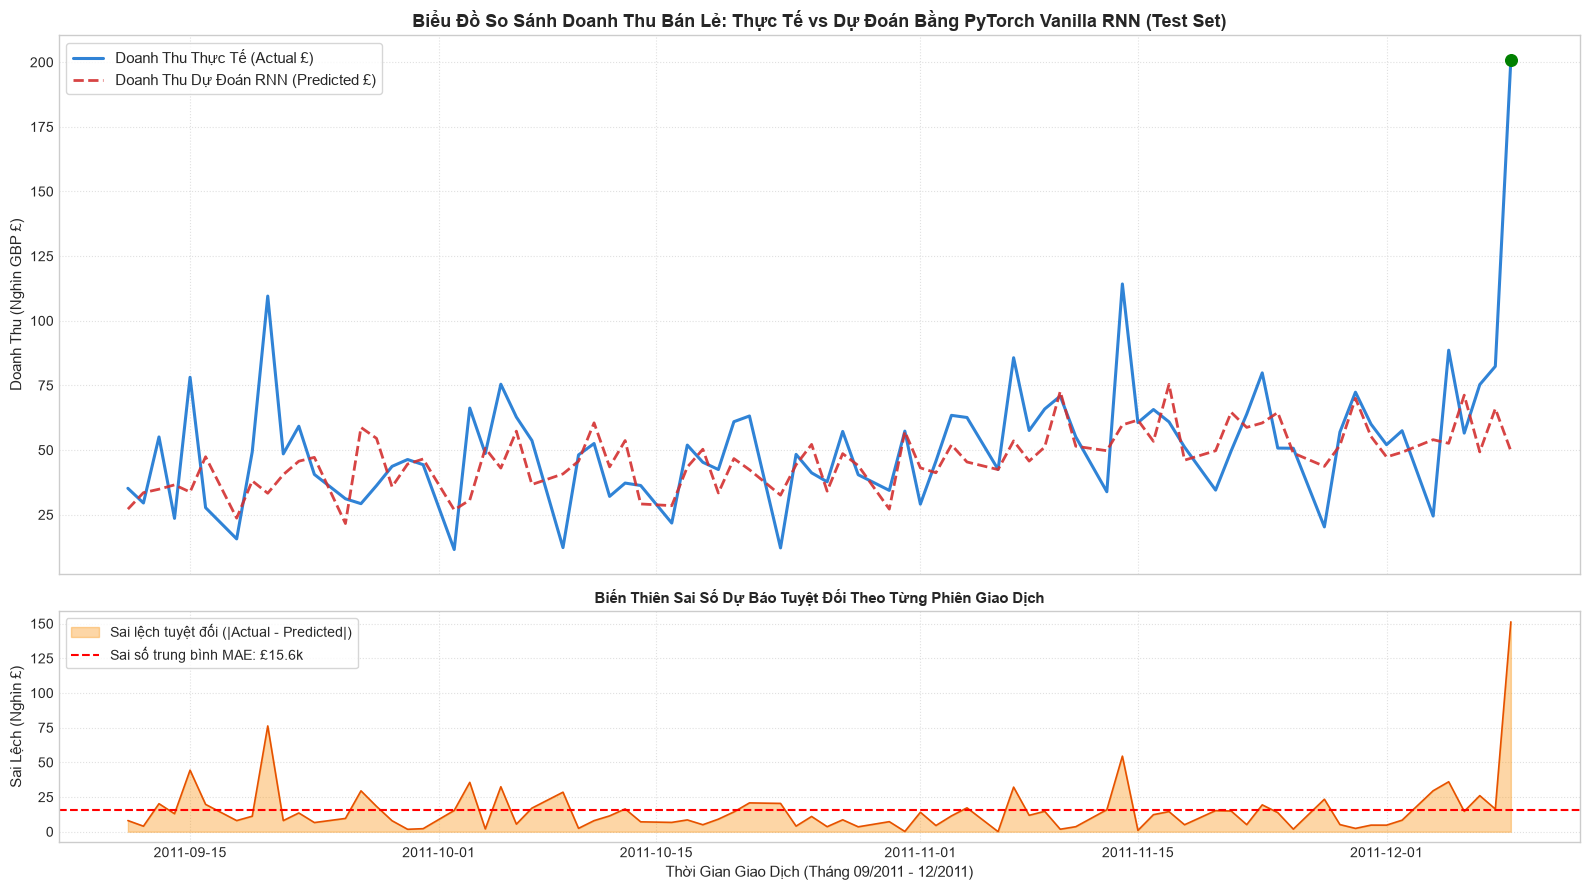

In [19]:
# Trực quan hóa Actual vs Predicted và Biểu đồ sai số Residuals trên Test Set
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={'height_ratios': [2.8, 1.2]})

# --- ĐỒ THỊ 1: ACTUAL VS PREDICTED DAILY REVENUE ---
axes[0].plot(df_test_comparison['Ngày giao dịch'], df_test_comparison['Doanh thu thực tế (Actual £)'] / 1e3, 
             label='Doanh Thu Thực Tế (Actual £)', color='#1976D2', linewidth=2.2, alpha=0.9)
axes[0].plot(df_test_comparison['Ngày giao dịch'], df_test_comparison['Doanh thu dự đoán (Predicted £)'] / 1e3, 
             label='Doanh Thu Dự Đoán RNN (Predicted £)', color='#D32F2F', linewidth=2.0, linestyle='--', alpha=0.9)
axes[0].set_title("Biểu Đồ So Sánh Doanh Thu Bán Lẻ: Thực Tế vs Dự Đoán Bằng PyTorch Vanilla RNN (Test Set)", 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel("Doanh Thu (Nghìn GBP £)", fontsize=11)
axes[0].legend(fontsize=11, loc='upper left', frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Đánh dấu ngày đạt đỉnh kỷ lục trong tập Test
max_test_idx = df_test_comparison['Doanh thu thực tế (Actual £)'].idxmax()
axes[0].scatter(df_test_comparison.loc[max_test_idx, 'Ngày giao dịch'], 
                df_test_comparison.loc[max_test_idx, 'Doanh thu thực tế (Actual £)'] / 1e3,
                color='green', s=70, zorder=5, 
                label=f"Đỉnh: £{df_test_comparison.loc[max_test_idx, 'Doanh thu thực tế (Actual £)']/1e3:.1f}k")

# --- ĐỒ THỊ 2: ABSOLUTE ERROR THEO THỜI GIAN ---
axes[1].fill_between(df_test_comparison['Ngày giao dịch'], df_test_comparison['Sai lệch tuyệt đối (£)'] / 1e3, 
                     color='#FB8C00', alpha=0.35, label='Sai lệch tuyệt đối (|Actual - Predicted|)')
axes[1].plot(df_test_comparison['Ngày giao dịch'], df_test_comparison['Sai lệch tuyệt đối (£)'] / 1e3, 
             color='#E65100', linewidth=1.2)
axes[1].axhline(mae / 1e3, color='red', linestyle='--', linewidth=1.5, label=f"Sai số trung bình MAE: £{mae/1e3:.1f}k")
axes[1].set_title("Biến Thiên Sai Số Dự Báo Tuyệt Đối Theo Từng Phiên Giao Dịch", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Thời Gian Giao Dịch (Tháng 09/2011 - 12/2011)", fontsize=11)
axes[1].set_ylabel("Sai Lệch (Nghìn £)", fontsize=11)
axes[1].legend(fontsize=10, loc='upper left', frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


---
<a id="section-22"></a>
## 22. Phân Tích Chuyên Sâu Kết Quả Dự Báo Bán Lẻ

### 22.1. RNN đã học được những mẫu hình (Patterns) nào?
* **Kết quả thực nghiệm**: **MAE = £15,567.14**; **MSE = 641,967,395.27**; **RMSE = £25,337.08**; **MAPE = 33.83%**; **R² = 0.0623**. WAPE = **29.64%**; sMAPE = **30.79%**.
* Baseline persistence trên **cùng 78 target**: MAE **£22,192.88**, RMSE **£30,387.10**, MAPE **53.58%**, R² **-0.3487**.
* RNN tốt hơn persistence theo MAE/RMSE, nhưng R² chỉ **0.0623**. Chưa chứng minh mô hình học được chu kỳ tuần chỉ từ đường dự báo; còn cần baseline theo mùa hoặc đặc trưng lịch.

---

### 22.2. Những giai đoạn mô hình dự đoán sai nhiều nhất:
Năm ngày có sai số lớn nhất, đơn vị GBP, được lấy từ chính dự báo của notebook:

| Ngày giao dịch | Thực tế | Dự đoán | Sai lệch tuyệt đối | Sai số (%) |
| :--- | ---: | ---: | ---: | ---: |
| `2011-12-09` | 200,918.98 | 49,626.04 | 151,292.94 | 75.30% |
| `2011-09-20` | 109,553.90 | 33,294.83 | 76,259.07 | 69.61% |
| `2011-11-14` | 114,237.40 | 59,746.32 | 54,491.08 | 47.70% |
| `2011-09-15` | 78,151.97 | 33,775.10 | 44,376.87 | 56.78% |
| `2011-12-05` | 88,620.84 | 52,607.69 | 36,013.15 | 40.64% |

* Ngày 09/12/2011 có doanh số bán dương **£200,918.98**, trong đó **£168,469.60** đến từ dòng bán có dòng hủy đối ứng sau 12 phút. Không gọi đây là doanh thu thuần hoặc mặc định nguyên nhân là mua sắm Giáng sinh.
* Bias toàn Test là **£-5,608.71**: mô hình có xu hướng dự báo thiếu trung bình. Chưa có dữ liệu để quy sai số cho dồn đơn sau kỳ nghỉ.

---

### 22.3. Tác động của Outliers & Missing Dates:
* RMSE cao hơn MAE cho thấy sai số không đồng đều; MSE phạt mạnh các sai số lớn. Không phải mọi outlier đều là thông tin kinh doanh hợp lệ đã hoàn tất.
* Thiếu 135 ngày lịch, gồm 104 Thứ Bảy; không có bằng chứng để khẳng định tất cả là ngày đóng cửa. Mô hình không nhận khoảng cách lịch giữa hai quan sát.
* MinMaxScaler và tanh không chặn dự báo trong [0,1] vì lớp Linear đầu ra không bị giới hạn ở khoảng đó.

---

### 22.4. Hạn chế của việc tổng hợp (Aggregate) thành Daily Time Series:
1. Bốn đặc trưng mất chi tiết mặt hàng, khách hàng và thời điểm trong ngày; AOV không thay thế toàn bộ phân bố giỏ hàng.
2. Mục tiêu là doanh số bán dương sau lọc, chưa đo doanh thu thuần sau hủy/hoàn trả.
3. Test chỉ đánh giá một bước với lịch sử thực đã có; chưa kiểm chứng dự báo đệ quy nhiều ngày hoặc độ bất định.


---
<a id="section-23"></a>
## 23. So Sánh Kỹ Thuật Toàn Diện Với Dataset Chứng Khoán S&P 500

### Bảng So Sánh Kỹ Thuật Đối Chiếu (Comparative Technical Analysis):

| Tiêu chí so sánh | Chứng khoán AAPL (Notebook 01) | Online Retail (Notebook 02) |
| :--- | :--- | :--- |
| **1. Loại dữ liệu** | OHLCV theo phiên của một mã cổ phiếu | Các dòng giao dịch tổng hợp theo ngày có bán hàng |
| **2. Target** | Giá đóng cửa phiên kế tiếp, USD | Doanh số bán dương của ngày có giao dịch kế tiếp, GBP |
| **3. Cấu trúc thời gian** | 20 phiên trước target; không đồng nhất với ngày lịch | 14 quan sát trước target; khoảng cách lịch không đều |
| **4. Đặc trưng** | 5 cột OHLCV | Doanh số, sản lượng, số hóa đơn và AOV |
| **5. Ngoại lai** | IQR là tiêu chí thống kê, không phải giới hạn cứng của giá | Đỉnh lớn cần kiểm tra giao dịch hủy và quy tắc lọc |
| **6. Đánh giá cùng miền dữ liệu** | MAE RNN $7.43 > persistence $1.50 | MAE RNN £15,567.14 < persistence £22,192.88 |
| **7. Phạm vi ứng dụng đã kiểm chứng** | Dự báo một bước trên lịch sử, chưa đánh giá lợi nhuận giao dịch | Dự báo một bước trên lịch sử, chưa đánh giá quyết định tồn kho hoặc dòng tiền |

> **Cách đọc**: Không xếp hạng hai bài toán bằng MAE khác đơn vị hoặc MSE đã scale khác nhau. Kết luận dựa trên đối chứng trong từng dataset; chưa xác định nguyên nhân kinh tế từ OHLCV hoặc các biến tổng hợp.


---
<a id="section-24"></a>
## 24. Conclusion (Tổng Kết Cuối Cùng)

Notebook này đã hoàn thành toàn diện toàn bộ quy trình khoa học dữ liệu từ làm sạch dữ liệu giao dịch thô, kỹ thuật đặc trưng, tổng hợp chuỗi thời gian, phân tích mùa vụ, đến xây dựng, huấn luyện và đánh giá mô hình **PyTorch Vanilla RNN** trên bài toán dự báo doanh thu bán lẻ trực tuyến.

---

### Bảng Tổng Hợp Hệ Thống Dự Án:

| Hạng mục tổng kết | Chi tiết thông số & Kết quả thực nghiệm |
| :--- | :--- |
| **Bộ dữ liệu (Dataset)** | **Online Retail II Data Set** (`dataset/online_retail_II.csv`), ghi nhận hơn $1$ triệu giao dịch thực tế của nhà bán lẻ Anh quốc (2009 - 2011). |
| **Tiền xử lý (Preprocessing)** | Loại 34,335 dòng trùng hoàn toàn theo giả định làm sạch, sau đó giữ dòng không hủy có Quantity > 0 và Price > 0: còn **1,007,913 dòng**. Các nhóm lỗi có chồng lấp, không cộng số đếm thô. Tổng hợp **604 ngày có giao dịch**, chưa khấu trừ hủy/hoàn trả. |
| **Thiết kế Sequence ($L$)** | **14 quan sát có giao dịch**, không phải đúng hai tuần lịch. Train / Val / Test có **408 / 76 / 78** cửa sổ. |
| **Đặc trưng (Features)** | Đa biến ($D = 4$): `['daily_revenue', 'daily_quantity', 'transaction_count', 'avg_order_value']`. |
| **Biến mục tiêu (Target)** | `daily_revenue` của ngày có giao dịch kế tiếp: tổng giá trị dòng bán dương, đơn vị GBP, chưa phải doanh thu thuần. |
| **Mô hình (Model)** | **Vanilla RNN Tối Giản**: `Input(14, 4) -> torch.nn.RNN(32, tanh) -> Linear(32, 1) -> Output(1)`. Tổng tham số: **$1,249$ tham số**. |
| **Huấn luyện (Training)** | Adam `lr=0.001`, MSE, 100 epoch, batch 16, shuffle=False; khôi phục epoch tốt nhất theo validation. |
| **Kết quả Đánh giá Test Set** | **MAE = £15,567.14**; **MSE = 641,967,395.27**; **RMSE = £25,337.08**; **MAPE = 33.83%**; **R² = 0.0623**. WAPE = **29.64%**; sMAPE = **30.79%**. |
| **Những kết quả chính** | Chạy **100 epoch**, chọn trọng số tại **epoch 100** theo validation. Train loss từ **0.057896** xuống **0.011963**; validation loss cuối **0.012322**, thấp nhất **0.012322**.<br>Baseline persistence trên **cùng 78 target**: MAE **£22,192.88**, RMSE **£30,387.10**, MAPE **53.58%**, R² **-0.3487**.<br>Vượt persistence theo MAE/RMSE nhưng R² gần 0, còn sai số lớn ở các đỉnh. |
| **Hạn chế (Limitations)** | Chưa dùng đặc trưng lịch; doanh số bán dương chịu ảnh hưởng dòng bán có hủy đối ứng; chưa đánh giá baseline theo mùa, dự báo nhiều bước hoặc deploy. |
| **Hướng Cải Thiện Mở Rộng** | 1. **Nâng cấp kiến trúc lên LSTM / GRU**: Bổ sung các cổng nhớ để ghi nhớ dài hạn hơn xu hướng tháng.<br>2. **Tách rời mô hình (Two-stage Model)**: Kết hợp mô hình phân loại (dự đoán có phát sinh đơn hàng bán buôn lớn hay không) kết hợp mô hình hồi quy doanh thu thông thường.<br>3. **Bổ sung đặc trưng Calendar**: Mã hóa One-hot cho thứ trong tuần (`DayOfWeek`), tháng trong năm (`Month`), và các cờ ngày lễ (Holiday flags). |

---
**KẾT THÚC NOTEBOOK 02 THÀNH CÔNG VÀ TRỌN VẸN!**
